# **1. CHUẨN BỊ CHO BÀI TOÁN**

In [1]:
import json 
import numpy as np 
import pandas as pd 
import time 
import warnings

from pathlib import Path 
from scipy import stats 
import math 
import textwrap
from datetime import date, timedelta
from functools import lru_cache

import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.patches import Patch

ROOT = Path()
DATA = ROOT / 'DATA'
RESULTS = ROOT / 'RESULTS'
IMAGES = ROOT / "IMAGES"
RESULTS.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)

In [2]:
# Phong cách biểu đồ chung 
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlelocation": "left", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "font.size": 10, "legend.frameon": False, "legend.fontsize": 9,
    "font.family": "DejaVu Sans",
})

# Bảng màu: mỗi màu mang một ý nghĩa cố định trong toàn bài
C = dict(ink="#15202B", ink2="#3D4B5A", grey="#9AA5B1", light="#D9DFE5",
         accent="#0E7C8F", accent2="#0E5A6B", warn="#D98E04", bad="#C0392B", good="#2E8B57")

def save_fig(name):
    plt.tight_layout()
    plt.savefig(IMAGES / f"{name}.png", bbox_inches="tight")
    plt.show()

## **1.1. Hằng số của bài toán**

"""
giải thích về khoảng đệm: dự báo không thể tạo ra và áp dụng ngay lập tức trong 0 giây, cần có khoảng đệm để mô hình mù thông tin về tháng 6, ép mô hình phải học cách dự báo cho tương lai xa dựa trên dữ liệu cũ hơn. Ví dụ, nếu được biết dữ liệu đến ngày 30/6 để dự đoán, doanh nghiệp không kịp chuẩn bị kho hàng. Khoảng đệm tháng 6 chính là thời gian để doanh nghiệp hành động dựa trên kết quả dự báo đó 
"""

In [3]:
SEED = 42 
H = 28 
TARGET = 'revenue'

# chia theo mốc: dự đoán doanh thu cho khoảng 6 tháng cuối năm, đệm trọn tháng 6
# dài hơn H=28 ngày tránh rò rỉ dữ liệu 
FOLDS = [
    ('Fold 1', '2019-05-31', '2019-07-31', '2019-12-31'),
    ('Fold 2', '2020-05-31', '2020-07-31', '2020-12-31'),
    ('Fold 3', '2021-05-31', '2021-07-31', '2021-12-31')
]
TEST_FOLD = ('TEST', '2022-05-31', '2022-07-31', '2022-12-31')

# Các ngày tết nguyên đán
TET_DATES = ["2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
             "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
             "2022-02-01", "2023-01-22"]

# Ngày lễ chính thức 
RETAIL_SPECIAL_DAYS = [(1, 1), (3, 8), (4, 30), (5, 1), (9, 2),
                       (10, 20), (11, 11), (12, 12), (12, 24), (12, 25)]

# tinh chỉnh siêu tham số
N_TRIALS = 40           # số lần thử của Optuna cho mỗi hình. 
ES_ROUNDS = 50          # dừng sớm nếu 50 cây liên tiếp không cải thiện tập early stopping 
ES_HOLDOUT_DAYS = 91    # đuôi thời gian của tập huấn luyện dùng làm tập early stopping
ES_MAX_TREES = 3000     # tần số cây khi dò số cây tối ưu 

## **1.2. Ba tiện ích dùng lại nhiều lần**

In [4]:
def split_by_date(df, train_end, val_start, val_end):
    train = df[df.date <= train_end]
    valid = df[(df.date >= val_start) & (df.date <= val_end)]
    return train, valid 

## **1.3. Độ đo**

In [5]:
def metrics(y_true, y_pred):
    # WAPE: tổng sai lệch của dự báo so với tổng giá trị thực tế
    # bias: mô hình đang dự báo cao hơn hay thấp hơn thực tế bao nhiêu % 
    # R2: giải thích được mức độ biến động của actual tốt đến đâu 
    y = np.asarray(y_true, float)
    p = np.clip(np.asarray(y_pred, float), 0, None)
    return dict(WAPE=float(np.sum(np.abs(y-p)) / np.sum(y)),
                bias=float((p.mean() - y.mean()) / y.mean()),
                R2=float(1-np.sum((y-p) ** 2) / np.sum((y-y.mean()) ** 2)))

## **1.4. Ghi và đọc kết quả**

In [6]:
def save_results(obj, filename):
    path = RESULTS / f'{filename}.json' 
    path.write_text(json.dumps(obj, ensure_ascii=False, indent=2,
                               default=lambda o: o.tolist()), encoding='utf-8')

def load_results(filename):
    return json.loads((RESULTS / f'{filename}.json').read_text(encoding='utf-8'))

## **1.5. Năm mô hình cây**

In [7]:
# Cấu hình gốc của hai mô hình boosting. Gom vào một chỗ để bản mặc định và bản tinh chỉnh
# (Mục VI.4b) dựng từ cùng một nền, chỉ khác các tham số được Optuna đổi.
BOOSTING_BASE = dict(n_estimators=700, learning_rate=0.04, subsample=0.85,
                     colsample_bytree=0.85, reg_lambda=1.0, n_jobs=-1)

def build_boosting(name, params=None, seed=SEED):
    """Dựng LightGBM hoặc XGBoost. params (nếu có) ghi đè cấu hình gốc."""
    import lightgbm as lgb
    import xgboost as xgb
    cfg = {**BOOSTING_BASE, **(params or {})}
    if name == "LightGBM":
        return lgb.LGBMRegressor(**{"num_leaves": 31, "min_child_samples": 20,
                                    "subsample_freq": 5, "verbose": -1, **cfg},
                                 random_state=seed)
    if name == "XGBoost":
        return xgb.XGBRegressor(**{"max_depth": 5, "tree_method": "hist", **cfg},
                                random_state=seed)
    raise ValueError(name)


def get_models(seed=SEED):
    """Năm mô hình cây của Module 03, xếp theo độ phức tạp tăng dần.

    Đặt ở đây vì cả bước kiểm rò rỉ, bước huấn luyện và bước giải thích đều dùng
    chung một cấu hình. Nếu mỗi tệp tự khai báo thì rất dễ lệch nhau.
    """
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

    return {
        "DecisionTree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=15,
                                              random_state=seed),
        "RandomForest": RandomForestRegressor(n_estimators=400, max_depth=14,
                                              min_samples_leaf=3, n_jobs=-1,
                                              random_state=seed),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                      max_depth=4, subsample=0.85,
                                                      random_state=seed),
        "XGBoost": build_boosting("XGBoost", seed=seed),
        "LightGBM": build_boosting("LightGBM", seed=seed),
    }

In [8]:
def fit_with_early_stopping(name, params, train, columns, seed=SEED):
    """Huấn luyện LightGBM/XGBoost với số cây do early stopping quyết định.

    Bước 1: dò số cây trên đuôi thời gian của tập huấn luyện (có khoảng đệm H ngày).
    Bước 2: huấn luyện lại trên toàn bộ tập huấn luyện với số cây đã dò (cộng 10%).
    Không bao giờ nhìn dữ liệu ngoài `train`. Mục tiêu là log1p(doanh thu), như phần còn lại của bài.
    """
    import lightgbm as lgb
    cut = train["date"].max() - pd.Timedelta(days=ES_HOLDOUT_DAYS)
    inner_train = train[train["date"] <= cut - pd.Timedelta(days=H)]
    inner_valid = train[train["date"] > cut]
    X_in, y_in = inner_train[columns], np.log1p(inner_train[TARGET].values)
    X_es, y_es = inner_valid[columns], np.log1p(inner_valid[TARGET].values)

    probe = build_boosting(name, {**params, "n_estimators": ES_MAX_TREES}, seed=seed)
    if name == "LightGBM":
        probe.fit(X_in, y_in, eval_set=[(X_es, y_es)],
                  callbacks=[lgb.early_stopping(ES_ROUNDS, verbose=False)])
        best = probe.best_iteration_ or ES_MAX_TREES
    else:
        probe.set_params(early_stopping_rounds=ES_ROUNDS)
        probe.fit(X_in, y_in, eval_set=[(X_es, y_es)], verbose=False)
        best = probe.best_iteration + 1

    n_final = max(50, int(best * 1.1))
    final = build_boosting(name, {**params, "n_estimators": n_final}, seed=seed)
    final.fit(train[columns], np.log1p(train[TARGET].values))
    return final

# **2. PHÂN TÍCH CẤU TRÚC DỮ LIỆU**

In [9]:
R = {'checks': []}

def check(name, passed, detail):
    R['checks'].append({'name': name, 'passed': bool(passed), 'detail': detail})
    print(f'{'ĐẠT ' if passed else 'HỎNG'} {name:30s} {detail}')
    return passed 

raw = pd.read_csv(DATA / 'sales.csv', dtype=str)
date_text = raw.Date.astype(str).str.strip()

print('*' * 50)
print(f"  Tệp sales.csv: {len(raw):,} dòng, {raw.shape[1]} cột")
print(f"  Tên cột: {', '.join(raw.columns)}")
print('*' * 50)

**************************************************
  Tệp sales.csv: 3,851 dòng, 3 cột
  Tên cột: Date, Revenue, COGS
**************************************************


## **2.1. Kiểm tra kiểu dữ liệu**

In [10]:
type_report = {}
for column in ('Revenue', 'COGS'):
    n_bad = int(pd.to_numeric(raw[column], errors='coerce').isna().sum())
    type_report[column] = n_bad
    check(f'{column} đọc được thành số', n_bad == 0, f'{n_bad:,} ô không đọc được')

bad_value = pd.to_numeric(raw.Revenue, errors='coerce').isna()
if bad_value.any():
    print('\nBa ô đầu tiên không đọc được:')
    for value in raw.loc[bad_value, 'Revenue'].head(3):
        print(f'{value}')
    extra = sorted(set(''.join(raw.loc[bad_value, 'Revenue'])) - set('0123456789.'))
    print(f'Ký tự lạ duy nhất trong các ô đó: {extra}, tức dấu phân cách hàng nghìn')
    print('Một ô không ép được là cả cột giữ kiểu object, nên mọi phép tính hỏng theo')

    R['extra_characters'] = extra 
R['type_check'] = type_report

HỎNG Revenue đọc được thành số      308 ô không đọc được
HỎNG COGS đọc được thành số         308 ô không đọc được

Ba ô đầu tiên không đọc được:
4,612,623.19
1,204,115.66
2,971,078.12
Ký tự lạ duy nhất trong các ô đó: [','], tức dấu phân cách hàng nghìn
Một ô không ép được là cả cột giữ kiểu object, nên mọi phép tính hỏng theo


## **2.2. Kiểm tra định dạng ngày**

In [11]:
has_slash = date_text.str.contains('/', na=False)
has_time = date_text.str.contains(':', na=False)
n_slash, n_time = int(has_slash.sum()), int(has_time.sum())

check('Ngày dùng chung một định dạng', n_slash==0,
      f'{n_slash:,} dòng dùng dấu gạch chéo {len(raw) - n_slash:,} dòng dùng dấu gạch ngang')
check('Ngày không kèm phần thời gian', n_time==0,
      f'{n_time:,} dòng có phần thời gian')
form = (pd.Series(np.where(has_slash, 'dd/mm/yyyy', 'yyyy-mm-dd'), index=raw.index)
        + np.where(has_time, ' hh:mm:ss', ''))
print("\n  Các dạng gặp trong cột Date:")
print(form.value_counts().to_string())

HỎNG Ngày dùng chung một định dạng  213 dòng dùng dấu gạch chéo 3,638 dòng dùng dấu gạch ngang
HỎNG Ngày không kèm phần thời gian  214 dòng có phần thời gian

  Các dạng gặp trong cột Date:
yyyy-mm-dd             3485
yyyy-mm-dd hh:mm:ss     153
dd/mm/yyyy              152
dd/mm/yyyy hh:mm:ss      61


In [12]:
time_part = date_text[has_time].str.split().str[1]
all_midnight = bool((time_part == '00:00:00').all())
print(f'\n Phần thời gian luôn bằng 00:00:00: {all_midnight}')

leading = date_text[has_slash].str.slice(0, 2).astype(int)
print(f'\n Số đứng đầu của nhóm gạch chéo chạy từ {leading.min()} đến {leading.max()}.')

R['date_format'] = {'slash': n_slash, 'time': n_time,
                    'iso_plain': int((~has_slash & ~has_time).sum()),
                    'slash_and_time': int((has_slash & has_time).sum()),
                    'all_midnight': all_midnight,
                    'max_leading_number': int(leading.max())}

date_only = date_text.str.split().str[0]
parsed_date = pd.Series(pd.NaT, index=raw.index, dtype='datetime64[ns]')
parsed_date[has_slash] = pd.to_datetime(date_only[has_slash], format='%d/%m/%Y')
parsed_date[~has_slash] = pd.to_datetime(date_only[~has_slash], format='%Y-%m-%d')


 Phần thời gian luôn bằng 00:00:00: True

 Số đứng đầu của nhóm gạch chéo chạy từ 1 đến 31.


## **2.3. Kiểm tra dữ liệu trùng**

In [13]:
is_duplicated = parsed_date.duplicated(keep=False)
n_duplicated_rows = int(is_duplicated.sum())
n_duplicated_days = int(parsed_date[is_duplicated].nunique())
check('Không có ngày ghi trùng', n_duplicated_rows == 0,
      f'{n_duplicated_days} ngày, {n_duplicated_rows} dòng')

if n_duplicated_rows:
    same_values = raw.loc[is_duplicated, ['Revenue', 'COGS']].assign(
        d=parsed_date[is_duplicated]).duplicated(keep=False).all() # gia tri trung nhau
    print(f"\n  Các dòng trùng mang giá trị y hệt nhau: {bool(same_values)}")
    R['duplicate_identical'] = bool(same_values)

R['duplicate'] = {'rows': n_duplicated_rows, 'days': n_duplicated_days}
    

HỎNG Không có ngày ghi trùng        18 ngày, 36 dòng

  Các dòng trùng mang giá trị y hệt nhau: True


## **2.4. Kiểm tra ngày thiếu**

In [14]:
unique_date = parsed_date.drop_duplicates().sort_values()
gap = unique_date.diff().dropna().dt.days
n_gap = int((gap != 1).sum())
check('Chuỗi ngày liên tục', n_gap == 0,
      f'khoảng cách lớn nhất {int(gap.max())} ngày, {n_gap} chỗ đứt')
check('Ngày tăng dần theo thứ tự dòng', parsed_date.is_monotonic_increasing,
      'đã tăng dần' if parsed_date.is_monotonic_increasing else 'có dòng đảo thứ tự')
R['continuity'] = {'gaps': n_gap, 'max_gap_days': int(gap.max()),
                   'motonoic': bool(parsed_date.is_monotonic_increasing),
                   'first': str(unique_date.min().date()),
                   'last': str(unique_date.max().date()),
                   'n_days': int(len(unique_date))}
print(f"\n  Chuỗi trải từ {unique_date.min().date()} đến {unique_date.max().date()},"
      f" {len(unique_date):,} ngày khác nhau")

ĐẠT  Chuỗi ngày liên tục            khoảng cách lớn nhất 1 ngày, 0 chỗ đứt
ĐẠT  Ngày tăng dần theo thứ tự dòng đã tăng dần

  Chuỗi trải từ 2012-07-04 đến 2022-12-31, 3,833 ngày khác nhau


## **2.5. Kiểm tra giá trị thiếu**

In [15]:
n_missing = int(raw.isna().sum().sum())
check('Không có giá trị thiếu', n_missing == 0, f'{n_missing} ô có giá trị thiếu')
R['missing'] = n_missing

ĐẠT  Không có giá trị thiếu         0 ô có giá trị thiếu


## **TỔNG KẾT**

In [16]:
failed = [c for c in R['checks'] if not c['passed']]
print(f"  Chạy {len(R['checks'])} phép kiểm, {len(failed)} phép báo hỏng.\n")

for item in failed:
    print(f'     . {item['name']}: {item['detail']}')
    
R['n_failed'] = len(failed)
save_results(R, '01_structure')


  Chạy 8 phép kiểm, 5 phép báo hỏng.

     . Revenue đọc được thành số: 308 ô không đọc được
     . COGS đọc được thành số: 308 ô không đọc được
     . Ngày dùng chung một định dạng: 213 dòng dùng dấu gạch chéo 3,638 dòng dùng dấu gạch ngang
     . Ngày không kèm phần thời gian: 214 dòng có phần thời gian
     . Không có ngày ghi trùng: 18 ngày, 36 dòng


# **3. LÀM SẠCH DỮ LIỆU**

In [17]:
# 1. Ép Revenue, COGS về kiểu số 
R = {}
raw = pd.read_csv(DATA / "sales.csv", dtype=str)
df = raw.rename(columns={'Date': 'date', 'Revenue': 'revenue', 'COGS': 'cogs'})
n_input = len(df)

print(f"Đọc vào {n_input:,} dòng từ sales.csv")

Đọc vào 3,851 dòng từ sales.csv


## **3.1. Chuyển doanh thu về kiểu số**

In [18]:
converted = {}
for column in ('revenue', 'cogs'):
    text = df[column].astype(str).str.strip()
    n_string = int(text.str.contains(',', regex=False).sum())
    df[column] = text.str.replace(',', '', regex=False).astype(float)
    converted[column] = n_string
    print(f"  {column:8s}: bỏ dấu phân cách ở {n_string:,} ô,"
          f" kiểu cột thành {df[column].dtype}")
R['string_values'] = converted
print(f"  Kiểm lại khoảng giá trị: doanh thu từ {df.revenue.min():,.0f}"
      f" đến {df.revenue.max():,.0f}")
print("  Nếu lỡ bỏ nhầm dấu chấm thập phân thì khoảng giá trị sẽ nhảy lên"
      " hàng tỉ, và đó là dấu hiệu nhận ra ngay.")


  revenue : bỏ dấu phân cách ở 308 ô, kiểu cột thành float64
  cogs    : bỏ dấu phân cách ở 308 ô, kiểu cột thành float64
  Kiểm lại khoảng giá trị: doanh thu từ 279,814 đến 20,905,271
  Nếu lỡ bỏ nhầm dấu chấm thập phân thì khoảng giá trị sẽ nhảy lên hàng tỉ, và đó là dấu hiệu nhận ra ngay.


## **3.2. Cắt bỏ phần thời gian**

In [19]:
date_text = df.date.astype(str).str.strip()
has_time = date_text.str.contains(':', na=False)
n_time = int(has_time.sum())

time_part = date_text[has_time].str.split().str[1]
distinct_time = sorted(time_part.unique())
print(f'{n_time:,} dòng có chứa thời gian, giá trị gặp được: {distinct_time}')
assert distinct_time == ['00:00:00'], 'có giờ khác không, không được cắt bỏ'

date_text = date_text.str.split().str[0]
R['time_component'] = {'rows': n_time, 'value': distinct_time}

214 dòng có chứa thời gian, giá trị gặp được: ['00:00:00']


## **3.3. Thống nhất định dạng ngày**

In [20]:
has_slash = date_text.str.contains('/', na=False)
n_slash = int(has_slash.sum())

parsed = pd.Series(pd.NaT, index=date_text.index, dtype='datetime64[ns]')
parsed[has_slash] = pd.to_datetime(date_text[has_slash], format='%d/%m/%Y')
parsed[~has_slash] = pd.to_datetime(date_text[~has_slash], format='%Y-%m-%d')
df['date'] = parsed

print(f"  Đọc {n_slash:,} dòng theo dd/mm/yyyy và {n_input - n_slash:,} dòng theo yyyy-mm-dd")
print(f"  Cả hai nhóm cùng ghi ra một định dạng duy nhất là yyyy-mm-dd")
print(f"  Chuỗi trải từ {df.date.min().date()} đến {df.date.max().date()}")
R["date_format"] = {"slash": n_slash, "iso": n_input - n_slash}

df = df.sort_values("date").reset_index(drop=True)

  Đọc 213 dòng theo dd/mm/yyyy và 3,638 dòng theo yyyy-mm-dd
  Cả hai nhóm cùng ghi ra một định dạng duy nhất là yyyy-mm-dd
  Chuỗi trải từ 2012-07-04 đến 2022-12-31


## **3.4. Gộp các ngày trùng**

In [21]:
is_duplicated = df.date.duplicated(keep=False)
n_duplicated_rows = int(is_duplicated.sum())
n_duplicated_days = int(df.date[is_duplicated].nunique())
all_identical = bool(df[is_duplicated].duplicated(keep=False).all())

print(f"  Tìm thấy {n_duplicated_days} ngày ghi trùng, tổng {n_duplicated_rows} dòng")
print(f"  Các dòng trùng mang giá trị y hệt nhau: {all_identical}")

df = df.drop_duplicates(subset='date', keep='last').reset_index(drop=True)
print(f"  Còn lại {len(df):,} dòng sau khi gộp")
R['duplicate'] = {"days": n_duplicated_days, "rows": n_duplicated_rows,
                  "identical": all_identical, "rows_after": len(df)}

  Tìm thấy 18 ngày ghi trùng, tổng 36 dòng
  Các dòng trùng mang giá trị y hệt nhau: True
  Còn lại 3,833 dòng sau khi gộp


## **3.5. Kiểm tra dữ liệu sau xử lý**

In [22]:
gap = df.date.diff().dropna().dt.days
checks = {
    'số dòng khớp số ngày khác nhau': len(df) == df.date.nunique(),
    'kiểu doanh thu là số thực': df.revenue.dtype.kind == 'f',
    'kiểu giá vốn là số thực': df.cogs.dtype.kind == 'f',
    'không sinh ô rỗng': int(df.isna().sum().sum()) == 0,
    'ngày tăng dần': bool(df.date.is_monotonic_increasing),
    'chuỗi ngày liên tục': bool((gap==1).all()),
    'doanh thu đều dương': bool((df.revenue > 0).all()),
}

for name, passed in checks.items():
    print(f"  {'ĐẠT ' if passed else 'HỎNG'}  {name}")
assert all(checks.values()), "kiểm tra sau xử lý thất bại"
R["post_checks"] = {k: bool(v) for k, v in checks.items()}

df.to_csv(DATA / "sales_clean.csv", index=False)
R["n_input"] = n_input
R["n_output"] = len(df)
print(f"\n  {n_input:,} dòng vào, {len(df):,} dòng ra")
print(f"  Chênh lệch {n_input - len(df)} dòng đúng bằng số bản sao đã gộp")

save_results(R, '02_clean')

  ĐẠT   số dòng khớp số ngày khác nhau
  ĐẠT   kiểu doanh thu là số thực
  ĐẠT   kiểu giá vốn là số thực
  ĐẠT   không sinh ô rỗng
  ĐẠT   ngày tăng dần
  ĐẠT   chuỗi ngày liên tục
  ĐẠT   doanh thu đều dương

  3,851 dòng vào, 3,833 dòng ra
  Chênh lệch 18 dòng đúng bằng số bản sao đã gộp


# **4. PHÂN TÍCH CHUỖI DOANH THU**

In [23]:
R = {}
sales = pd.read_csv(DATA / "sales_clean.csv", parse_dates=["date"])
revenue = sales.revenue

print(f"Đọc {len(sales):,} dòng từ sales_clean.csv,"
      f" từ {sales.date.min().date()} đến {sales.date.max().date()}")

Đọc 3,833 dòng từ sales_clean.csv, từ 2012-07-04 đến 2022-12-31


## **4.1. Mức doanh thu qua các năm**

In [24]:
by_year = sales.groupby(sales.date.dt.year).revenue.agg(daily_mean='mean', n_days='count')
by_year['change_pct'] = by_year.daily_mean.pct_change() * 100 
print(by_year.round(2).rename_axis('year').to_string())

break_year = int(by_year.change_pct.idxmin())
break_pct = float(by_year.change_pct.min())
level_before = float(by_year.loc[2013:2018, 'daily_mean'].mean())
level_after = float(by_year.loc[2020:2022, 'daily_mean'].mean())

by_year_out = by_year.astype(object).where(by_year.notna(), None)
R['by_year'] = {int(year): row for year, row in by_year_out.to_dict('index').items()}
R['level_break'] = {'year': break_year, 'drop_pct': break_pct,
                    'level_2013_2018': level_before, 'level_2020_2022': level_after,
                    'ratio': level_before/level_after}

print(f"\n  Mức sụt mạnh nhất rơi vào năm {break_year} với {break_pct:.2f}%")
print(f"  Giai đoạn 2013 đến 2018 trung bình {level_before:,.0f} mỗi ngày")
print(f"  Giai đoạn 2020 đến 2022 trung bình {level_after:,.0f} mỗi ngày")
print(f"  Chênh {level_before / level_after:.2f} lần, tức chuỗi có hai mức chứ không phải một")
print(f"\n  Năm 2012 chỉ có {int(by_year.loc[2012, 'n_days'])} ngày, toàn bộ ở nửa cuối năm,")
print("  nên không đem so trực tiếp với các năm khác được vì khoảng"
      " thời gian không cùng độ dài.")

      daily_mean  n_days  change_pct
year                                
2012  4096672.64     181         NaN
2013  4540190.18     365       10.83
2014  5128344.88     365       12.95
2015  5177900.90     365        0.97
2016  5750384.36     366       11.06
2017  5236066.64     365       -8.94
2018  5068828.65     365       -3.19
2019  3114524.50     365      -38.56
2020  2881180.76     366       -7.49
2021  2857643.34     365       -0.82
2022  3204791.32     365       12.15

  Mức sụt mạnh nhất rơi vào năm 2019 với -38.56%
  Giai đoạn 2013 đến 2018 trung bình 5,150,286 mỗi ngày
  Giai đoạn 2020 đến 2022 trung bình 2,981,205 mỗi ngày
  Chênh 1.73 lần, tức chuỗi có hai mức chứ không phải một

  Năm 2012 chỉ có 181 ngày, toàn bộ ở nửa cuối năm,
  nên không đem so trực tiếp với các năm khác được vì khoảng thời gian không cùng độ dài.


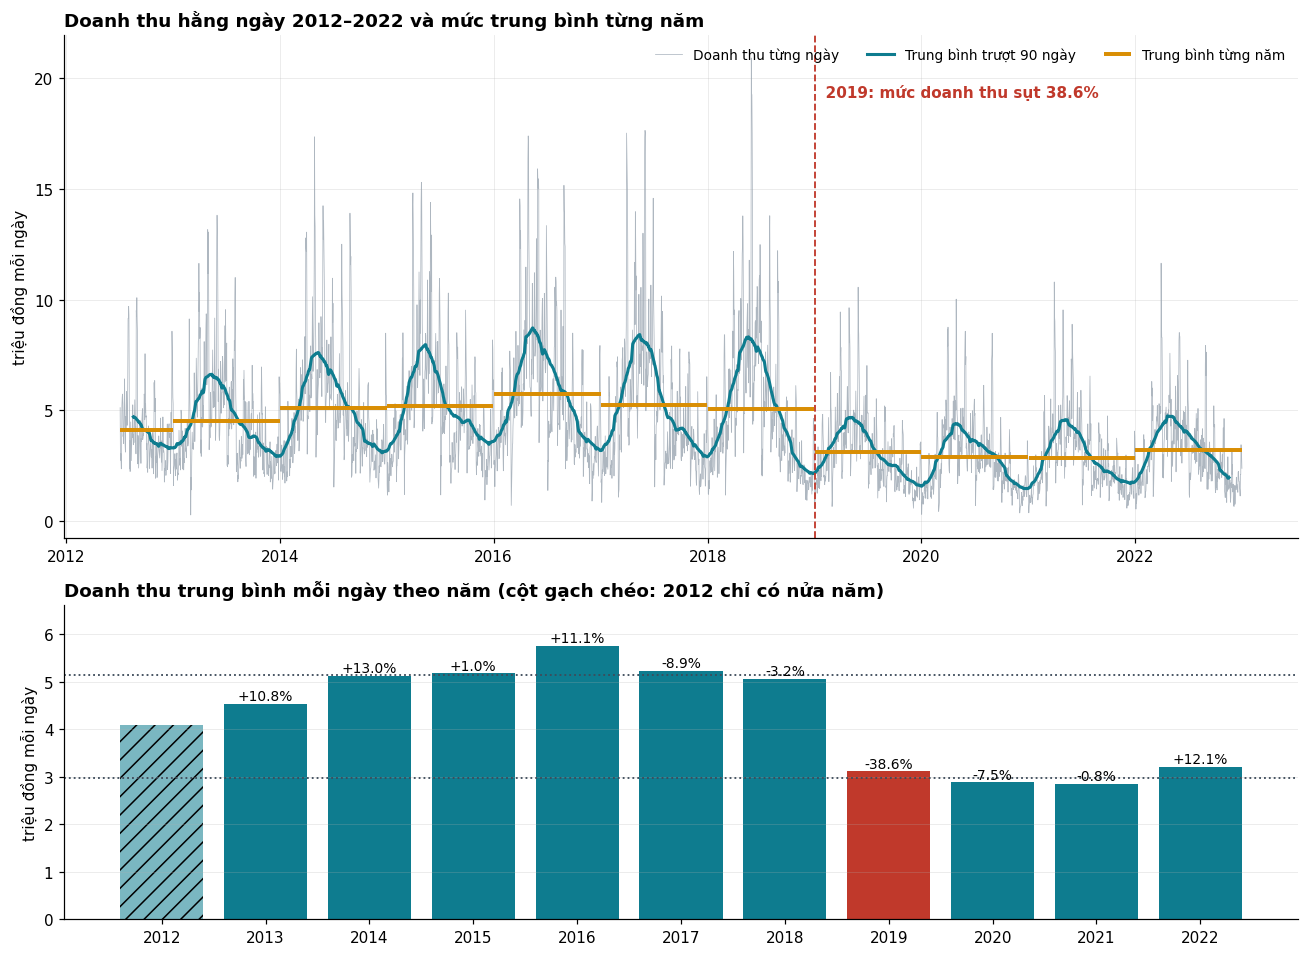

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8.8), gridspec_kw={"height_ratios": [1.6, 1]})

ax1.plot(sales.date, revenue / 1e6, color=C["grey"], lw=0.5, alpha=0.8, label="Doanh thu từng ngày")
ax1.plot(sales.date, revenue.rolling(90, center=True).mean() / 1e6, color=C["accent"], lw=2,
         label="Trung bình trượt 90 ngày")
for year, g in sales.groupby(sales.date.dt.year):
    ax1.hlines(g.revenue.mean() / 1e6, g.date.min(), g.date.max(), color=C["warn"], lw=2.6,
               label="Trung bình từng năm" if year == 2012 else None)
break_date = pd.Timestamp(f"{break_year}-01-01")
ax1.axvline(break_date, color=C["bad"], ls="--", lw=1.2)
ax1.text(break_date, ax1.get_ylim()[1] * 0.9, f"  {break_year}: mức doanh thu sụt {abs(break_pct):.1f}%",
         color=C["bad"], va="top", fontsize=10, fontweight="bold")
ax1.set(ylabel="triệu đồng mỗi ngày", title="Doanh thu hằng ngày 2012–2022 và mức trung bình từng năm")
ax1.legend(loc="upper right", ncol=3)

colors = [C["bad"] if y == break_year else C["accent"] for y in by_year.index]
bars = ax2.bar(by_year.index.astype(str), by_year.daily_mean / 1e6, color=colors)
bars[0].set_hatch("//"); bars[0].set_alpha(0.55)          # 2012 chỉ có nửa năm
for bar, pct in zip(bars, by_year.change_pct):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
             "" if pd.isna(pct) else f"{pct:+.1f}%", ha="center", fontsize=9)
ax2.axhline(level_before / 1e6, color=C["ink2"], ls=":", lw=1.2)
ax2.axhline(level_after / 1e6, color=C["ink2"], ls=":", lw=1.2)
ax2.set(ylabel="triệu đồng mỗi ngày", ylim=(0, by_year.daily_mean.max() / 1e6 * 1.15),
        title="Doanh thu trung bình mỗi ngày theo năm (cột gạch chéo: 2012 chỉ có nửa năm)")
ax2.grid(axis="x", visible=False)
save_fig("01_doanh_thu_theo_nam")

**Đọc kết quả và quyết định**
- Doanh thu trung bình mỗi ngày khoảng 5 triệu từ 2013-2018 rồi sụt 38.6% vào 2019 và ở mức thấp sau đó (2020-2022 chỉ khoảng 3 triệu).
- Hệ quả trực tiếp cho mô hình hóa: một mô hình học từ giai đoạn mức cao rồi bị đem dự báogiao đoạn mức thấp sẽ dự báo cao vọt. Nếu gộp mọi lần cắt kiểm định vào một con số trung bình, lần cắt rơi đúng vào điểm gãy sẽ kéo lệch toàn bộ điểm số
- Năm 2012 chỉ có nửa năm nên không so sánh trực tiếp được
- **Quyết định:** lần cắt kiểm định rơi vào năm 2019 (Fold 1) được tách riêng; số CV chỉ lấy trung bình các lần cắt sau điểm gãy. Fold 1 vẫn được báo cáo như một phép thử sức chịu đựng 

## **4.2. Phân phối doanh thu**

In [26]:
n_negative = int((revenue < 0).sum())
n_zero = int((revenue == 0).sum())
print(f'   Số ngày doanh thu âm: {n_negative}            Số ngày doanh thu bằng 0: {n_zero}')

skew_raw = float(stats.skew(revenue))
skew_log = float(stats.skew(np.log1p(revenue)))
print(f"\n  Độ lệch thang gốc : {skew_raw:+.3f}")
print(f"  Độ lệch sau log1p : {skew_log:+.3f}")
print(f"  Lớn nhất chia trung vị: {revenue.max() / revenue.median():.2f} lần")
print(f"  Khoảng giá trị: {revenue.min():,.0f} đến {revenue.max():,.0f}")

R['distribution'] = {'skew': skew_raw, 'skew_log1p': skew_log,
                     'max_over_median': float(revenue.max() / revenue.median()),
                     'cv': float(revenue.std() / revenue.mean()),
                     'n_negative': n_negative, 'n_zero': n_zero,
                     'min': float(revenue.min()), 'max': float(revenue.max()),
                     'median': float(revenue.median())}

print('  Phân phối lệch phải, RMSE không hợp, vì vài ngày cực'
      ' trị sẽ chi phối toàn bộ con số')

   Số ngày doanh thu âm: 0            Số ngày doanh thu bằng 0: 0

  Độ lệch thang gốc : +1.669
  Độ lệch sau log1p : -0.159
  Lớn nhất chia trung vị: 5.73 lần
  Khoảng giá trị: 279,814 đến 20,905,271
  Phân phối lệch phải, RMSE không hợp, vì vài ngày cực trị sẽ chi phối toàn bộ con số


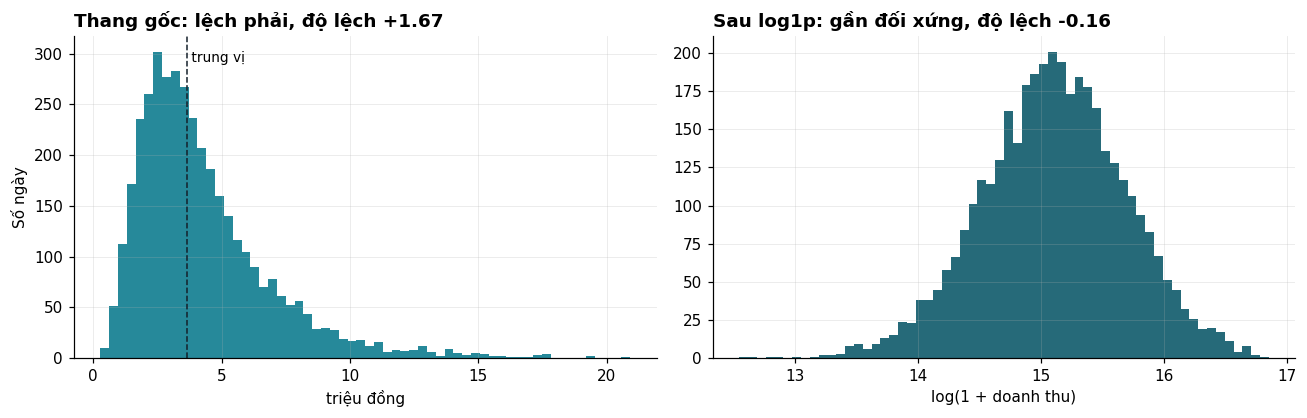

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
axes[0].hist(revenue / 1e6, bins=60, color=C["accent"], alpha=0.9)
axes[0].axvline(revenue.median() / 1e6, color=C["ink"], ls="--", lw=1)
axes[0].text(revenue.median() / 1e6, axes[0].get_ylim()[1] * 0.92, " trung vị", fontsize=9)
axes[0].set(xlabel="triệu đồng", ylabel="Số ngày", title=f"Thang gốc: lệch phải, độ lệch {skew_raw:+.2f}")
axes[1].hist(np.log1p(revenue), bins=60, color=C["accent2"], alpha=0.9)
axes[1].set(xlabel="log(1 + doanh thu)", title=f"Sau log1p: gần đối xứng, độ lệch {skew_log:+.2f}")
save_fig("02_phan_phoi_doanh_thu")

**Đọc kết quả và quyết định**
- Độ lệch giảm từ 1.669 xuống -0.159 sau log1p, ngày lớn nhất gấp 5.73 lần trung vị. Không có ngày doanh thu âm hay bằng 0, nên log1p an toàn.
- Phân phối lệch phải như vậy thì ngày cực trị sẽ chi phối toàn bộ RMSE
- **Quyết định(1):** huấn luyện trên `log1p(revenue)`
- **Quyết định(2):** dùng **WAPE**(tổng sai số tuyệt đối chia tổng doanh thu) làm độ đo chính, đo trên thang gốc để đọc được theo tiền thật 

## **4.3. Các ngày doanh thu cao bất thường**

In [28]:
q1, q3 = revenue.quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
lower = q1 - 1.5 * (q3 - q1)
is_high = revenue > upper 
is_low = revenue < lower 

end_of_month = sales.date.dt.day.isin([29, 30, 31, 1, 2])
share_eom = float(end_of_month[is_high].mean())

print(f'Ngưỡng trên: {upper:,.0f}')
print(f'Vượt ngưỡng: {int(is_high.sum())} ngày ({100 * is_high.mean():.1f}%)')
print(f'Dưới ngưỡng dưới: {int(is_low.sum())} ngày')
print(f'Tỉ lệ rơi vào cụm ngày 29, 30, 31, 1 và 2: {100 * share_eom:.1f}%')
print('\nBa ngày cao nhất:')
print(sales.nlargest(3, 'revenue')[['date', 'revenue']].to_string(index=False))

R['outlier'] = {'threshold': float(upper), 'n_high': int(is_high.sum()),
                'pct_high': float(100 * is_high.mean()),
                'n_low': int(is_low.sum()),
                'share_end_of_month': share_eom,
                'top3': [{'date': str(r.date.date()), 'revenue': float(r.revenue)}
                         for r in sales.nlargest(3, 'revenue').itertuples()]}

Ngưỡng trên: 9,670,560
Vượt ngưỡng: 169 ngày (4.4%)
Dưới ngưỡng dưới: 0 ngày
Tỉ lệ rơi vào cụm ngày 29, 30, 31, 1 và 2: 63.9%

Ba ngày cao nhất:
      date     revenue
2018-05-30 20905271.35
2018-05-31 19289944.12
2018-06-01 19245165.78


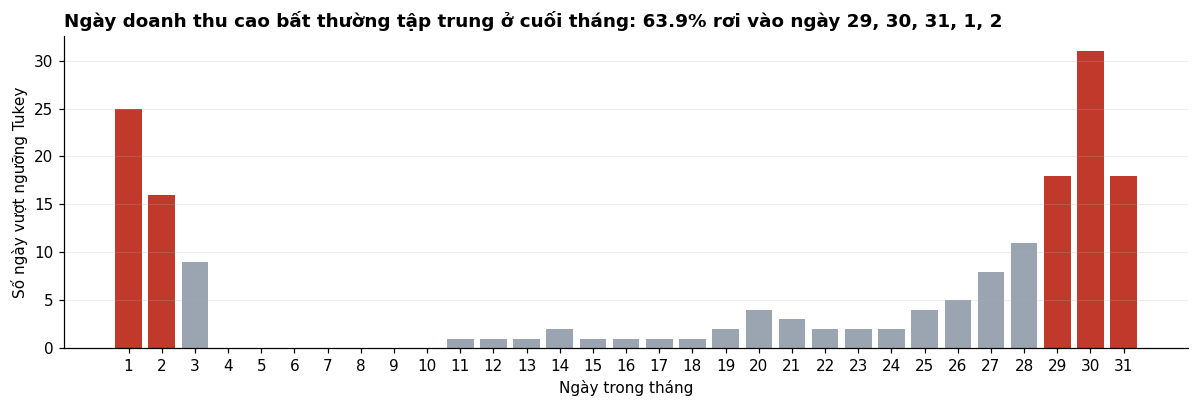

In [29]:
count_by_dom = sales.loc[is_high, 'date'].dt.day.value_counts().reindex(range(1, 32), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(count_by_dom.index, count_by_dom.values,
       color=[C["bad"] if d in (29, 30, 31, 1, 2) else C["grey"] for d in count_by_dom.index])
ax.set(xlabel="Ngày trong tháng", ylabel="Số ngày vượt ngưỡng Tukey",
       title=f"Ngày doanh thu cao bất thường tập trung ở cuối tháng: {100 * share_eom:.1f}% rơi vào ngày 29, 30, 31, 1, 2")
ax.set_xticks(range(1, 32))
ax.grid(axis="x", visible=False)
save_fig("03_ngay_cao_bat_thuong_theo_ngay_trong_thang")


**Đọc kết quả và quyết định**
- 169 ngày (4.4%) vượt ngưỡng Tukey, và 63.9% trong số đó rơi vào cụm ngày 29, 30, 31, 1, 2. Ba ngày cao nhất là 30/05/2018, 31/05/2018 và 01/06/2018. Không có ngày nào dưới ngưỡng dưới 
- Nếu các ngày này là nhiễu thì chúng rải đều trong tháng. Chúng dồn vào cụm cuối tháng nên là **quy luật có cấu trúc**
- **Quyết định:** giữ nguyên, không cắt bỏ. Cắt các ngày là xóa đúng tín hiệu mà mô hình cần học. 

## **4.4. Chu kỳ mùa vụ**

In [30]:
n_cycles = (sales.date.max() - sales.date.min()).days / 365.25
print(f'Chuỗi dài {n_cycles:.1f} chu kỳ năm, đủ để học mùa vụ năm')

# tính tỉ lệ doanh thu của từng dòng so với doanh thu trung bình năm  
sales['year_ratio'] = revenue / sales.groupby(sales.date.dt.year).revenue.transform('mean')
sales['month_ratio'] = revenue / sales.groupby(sales.date.dt.to_period('M')).revenue.transform('mean')

cycles = {}
for name, key in [('ngày trong tháng', sales.date.dt.day),
                  ('tháng', sales.date.dt.month),
                  ('thứ trong tuần', sales.date.dt.dayofweek)]:
    grouped = sales.groupby(key).year_ratio.mean()
    cycles[name] = {'peak_at': int(grouped.idxmax()), 'peak': float(grouped.max()),
                    'trough_at': int(grouped.idxmin()), 'trough': float(grouped.min()),
                    'amplitude': float(grouped.max() / grouped.min())}

print(pd.DataFrame(cycles).T.round(3).astype({'peak_at': int, 'trough_at': int}).rename_axis('chu kỳ').to_string())
R['seasonality'] = cycles
R['n_year_cycles'] = float(n_cycles)

is_31 = sales.date.dt.day == 31
R['day_31'] = {'by_year': float(sales.loc[is_31, 'year_ratio'].mean()),
               'by_month': float(sales.loc[is_31, 'month_ratio'].mean())}
print(f"\n  Ngày 31 chỉ tồn tại ở 7 trên 12 tháng nên phải kiểm chéo")
print(f"    chuẩn hoá theo năm  : {R['day_31']['by_year']:.3f}")
print(f"    chuẩn hoá theo tháng: {R['day_31']['by_month']:.3f}")

Chuỗi dài 10.5 chu kỳ năm, đủ để học mùa vụ năm
                  peak_at   peak  trough_at  trough  amplitude
chu kỳ                                                        
ngày trong tháng       31  1.763          4   0.620      2.844
tháng                   5  1.525         12   0.586      2.603
thứ trong tuần          2  1.090          5   0.911      1.197

  Ngày 31 chỉ tồn tại ở 7 trên 12 tháng nên phải kiểm chéo
    chuẩn hoá theo năm  : 1.763
    chuẩn hoá theo tháng: 1.784


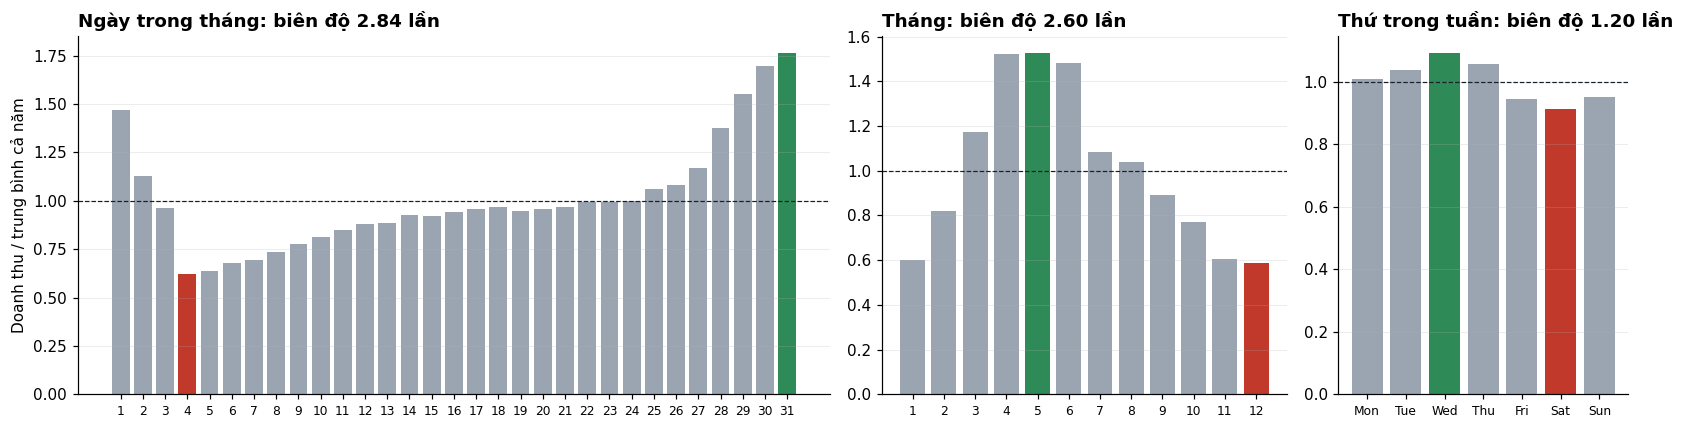

In [31]:
profiles = [('Ngày trong tháng', sales.date.dt.day),
            ('Tháng', sales.date.dt.month),
            ('Thứ trong tuần', sales.date.dt.dayofweek)]
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [2.6, 1.4, 1]})
for ax, (title, key) in zip(axes, profiles):
    g = sales.groupby(key).year_ratio.mean()
    colors = [C["good"] if v == g.max() else C["bad"] if v == g.min() else C["grey"] for v in g.values]
    ax.bar(range(len(g)), g.values, color=colors)
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(dow_names if title.startswith("Thứ") else g.index, fontsize=8)
    ax.axhline(1, color=C["ink"], lw=0.8, ls="--")
    ax.set_title(f"{title}: biên độ {g.max() / g.min():.2f} lần")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Doanh thu / trung bình cả năm")
save_fig("04_chu_ky_mua_vu")

**Đọc kết quả và quyết định**

| Tầng mùa vụ | Đỉnh | Đáy | Biên độ |
|---|---|---|---|
| Ngày trong tháng | ngày 31 (1.763) | ngày 4 (0.62) | 2.84 lần |
| Tháng | tháng 5 (1.525) | tháng 12 | 2.60 lần |
| Thứ trong tuần | (nhẹ) | (nhẹ) | 1.20 lần |

- Chuỗi có ít nhất 10 chu kỳ năm, đủ để học mùa vụ năm. Chu kỳ **ngày trong tháng** là mạnh nhất, mạnh hơn hẳn chu kỳ tuần (nhiều mô hình mặc định chỉ nghĩ đến thứ trong tuần).
- Ngày 31 chỉ tồn tại ở 7 trên 12 tháng nên đã được kiểm chéo: chuẩn hoá theo năm cho 1.763, theo tháng cho 1.784. Hai cách ra gần nhau, nên "đỉnh ngày 31" là thật, không phải ảo giác do thiếu mẫu.
- **Quyết định:** nhóm lịch phải có đặc trưng đếm ngược đến cuối tháng (`dom_reverse`), cờ cuối/đầu tháng, và mã hoá Fourier cho chu kỳ năm.

## **4.5. Tết, khuyến mãi và giá vốn**

In [32]:
tet = pd.to_datetime(TET_DATES)
offset = np.stack([(sales.date - t).dt.days.values for t in tet])
sales['days_to_tet'] = offset[np.abs(offset).argmin(axis=0), np.arange(len(sales))]

R['tet'] = {}
for name, lo, hi in [('30 đến 15 ngày trước', -30, -15),
                     ('14 đến 1 ngày trước', -14, -1),
                     ('mùng 1 đến mùng 7', 0, 7),
                     ('8 đến 21 ngày sau', 8, 21)]:
    window = sales.days_to_tet.between(lo, hi)
    R['tet'][name] = {'by_year': float(sales.loc[window, 'year_ratio'].mean()),
                      'by_month': float(sales.loc[window, 'month_ratio'].mean())}

print(pd.DataFrame(R['tet']).T.round(3).rename_axis('cửa sổ quanh Tết').to_string())

                      by_year  by_month
cửa sổ quanh Tết                       
30 đến 15 ngày trước    0.604     1.014
14 đến 1 ngày trước     0.680     0.993
mùng 1 đến mùng 7       0.771     1.011
8 đến 21 ngày sau       0.826     0.959


**Đọc kết quả và quyết định**
- Chia cho trung bình cả năm thì quanh Tết doanh thu chỉ bằng **0.60 đến 0.83** mức bình thường, một hiệu ứng rất mạnh. Nhưng chia cho trung bình của chính tháng đó thì tỉ lệ là **0.96 đến 1.01**, gần như không có gì
- Giải thích: Tết luôn rơi vào tháng 1 hoặc tháng 2, vốn đã là những tháng thấp theo mùa vụ. Phần lớn cái gọi là "hiệu ứng Tết" thực ra là **hiệu ứng tháng**.
- **Quyết định:** vẫn giữ nhóm đặc trưng Tết (chi phí thấp) nhưng kỳ vọng đóng góp nhỏ. Bước SHAP sẽ kiểm tra kỳ vọng này 

### **Khuyến mãi**

In [33]:
promotions = pd.read_csv(DATA / 'promotions.csv', parse_dates=['start_date', 'end_date'])
sales['has_promo'] = 0
for _, promo in promotions.iterrows():
    in_window = (sales.date >= promo.start_date) & (sales.date <= promo.end_date)
    sales.loc[in_window, 'has_promo'] = 1

with_promo = sales.loc[sales.has_promo == 1, 'month_ratio'].mean()
without_promo = sales.loc[sales.has_promo == 0, 'month_ratio'].mean()
covers = (promotions.start_date.min() <= sales.date.min() + pd.Timedelta(days=365)
          and promotions.end_date.max() >= sales.date.max() - pd.Timedelta(days=365))
R['promotion'] = {'n_programs': len(promotions),
                  'n_day_with': int((sales.has_promo == 1).sum()),
                  'ratio_with': float(with_promo),
                  'ratio_without': float(without_promo),
                  'lift_pct': float(100 * (with_promo / without_promo - 1)),
                  'covers_series': bool(covers),
                  'first': str(promotions.start_date.min().date()),
                  'last': str(promotions.end_date.max().date())}
print(f"\n  {len(promotions)} chương trình khuyến mãi, phủ từ {promotions.start_date.min().date()}"
      f" đến {promotions.end_date.max().date()}")
print(f"    ngày có khuyến mãi   : {with_promo:.3f}")
print(f"    ngày không khuyến mãi: {without_promo:.3f}")
print(f"    chênh lệch {100 * (with_promo / without_promo - 1):+.1f}%, kỳ vọng đóng góp nhỏ")


  50 chương trình khuyến mãi, phủ từ 2013-01-31 đến 2022-12-31
    ngày có khuyến mãi   : 1.010
    ngày không khuyến mãi: 0.992
    chênh lệch +1.9%, kỳ vọng đóng góp nhỏ


### **Giá vốn và biên lợi nhuận âm**

In [34]:
negative_margin = sales.cogs > revenue
# chia dữ liệu thành 5 nhóm có số lượng observation gần bằng nhau, labels=False là từ 0 đến 4
# Q0-Q4 là nhóm theo thứ hạng revenue, ko phải 5 khoảng giá trị bằng nhau 
quintile = pd.qcut(revenue, 5, labels=False)
share_by_quintile = (sales.assign(q=quintile, neg=negative_margin).groupby('q', observed=True).neg.mean() * 100)

R['cogs'] = {'correlation': float(revenue.corr(sales.cogs)),
             'mean_margin': float((1 - sales.cogs / revenue).mean()),
             'n_negative_margin': int(negative_margin.sum()),
             'pct_negative_margin': float(100 * negative_margin.mean()),
             'deepest': float((1 - sales.cogs / revenue).min()),
             'share_by_quintile': [float(v) for v in share_by_quintile]}

print(f'\n Giá vốn tương quan với doanh thu {revenue.corr(sales.cogs):.4f}, nhưng ghi cùng ngày')
print(f'\n Ngày biên lợi nhuận âm: {int(negative_margin.sum())}'
      f' ({100 * negative_margin.mean():.1f}%), sâu nhất {(1 - sales.cogs / revenue).min():.3f}')
print('    ' + '    '.join(f'{v:.1f}%' for v in share_by_quintile))


 Giá vốn tương quan với doanh thu 0.9760, nhưng ghi cùng ngày

 Ngày biên lợi nhuận âm: 382 (10.0%), sâu nhất -0.575
    21.4%    14.0%    7.4%    3.9%    3.1%


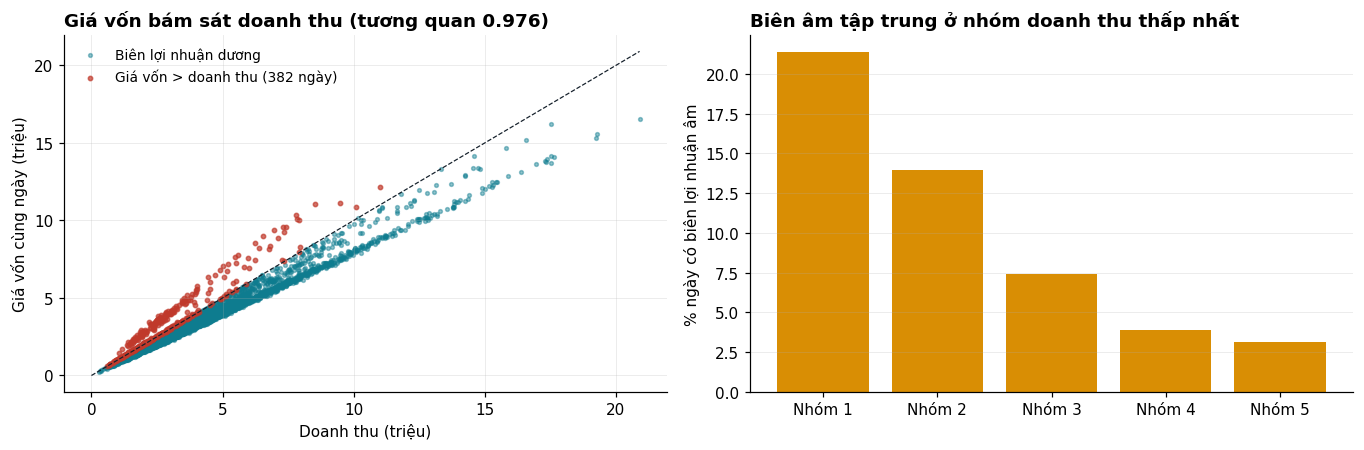

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ok = ~negative_margin
axes[0].scatter(revenue[ok] / 1e6, sales.cogs[ok] / 1e6, s=6, color=C["accent"], alpha=0.45, label="Biên lợi nhuận dương")
axes[0].scatter(revenue[negative_margin] / 1e6, sales.cogs[negative_margin] / 1e6, s=8, color=C["bad"],
                alpha=0.7, label=f"Giá vốn > doanh thu ({int(negative_margin.sum())} ngày)")
lim = max(revenue.max(), sales.cogs.max()) / 1e6
axes[0].plot([0, lim], [0, lim], color=C["ink"], lw=0.8, ls="--")
axes[0].set(xlabel="Doanh thu (triệu)", ylabel="Giá vốn cùng ngày (triệu)",
            title=f"Giá vốn bám sát doanh thu (tương quan {revenue.corr(sales.cogs):.3f})")
axes[0].legend(loc="upper left")
axes[1].bar([f"Nhóm {i + 1}" for i in range(len(share_by_quintile))], share_by_quintile.values, color=C["warn"])
axes[1].set(ylabel="% ngày có biên lợi nhuận âm", title="Biên âm tập trung ở nhóm doanh thu thấp nhất")
axes[1].grid(axis="x", visible=False)
save_fig("05_gia_von_va_bien_am")

**Đọc kết quả và quyết định**
- Giá vốn tương quan 0.976 với doanh thu. Đó là dấu hiệu nguy hiểm: giá vốn được ghi cùng ngày với doanh thu, nên tại thời điểm dự báo trước 28 ngày ta không có nó
- 382 ngày (10.0%) có biên lợi nhuận âm, tập trung ở nhóm doanh thu thấp nhất (21.4% so với 3.1% ở nhóm cao nhất). Điều này gợi ý giá vốn có một phần cố định, không tỉ lệ thuận với doanh thu ngày
- **Quyết định:** loại `cogs` khỏi mọi đặc trưng. Mục 5.3 sẽ chứng minh bằng thực nghiệm hậu quả khi đưa nó vào

## **4.6 Tương quan theo độ trễ**

In [36]:
z = sales.year_ratio
lags = [1, 3, 7, 14, 21, 28, 35, 42, 56, 91, 182, 273, 364, 546, 728]
acf = {lag: float(z.autocorr(lag)) for lag in lags}
R['acf'] = acf 

acf_table = pd.DataFrame({'acf': acf})
acf_table['status'] = np.where(acf_table.index >= H, 'dùng được', 'bị chặn')
print(acf_table.round(3).rename_axis('độ trễ').to_string())

allowed = {lag: value for lag, value in acf.items() if lag >= H}
best_lag = max(allowed, key=lambda k: abs(allowed[k]))
R['best_allowed_lag'] = {'lag': best_lag, 'value': allowed[best_lag]}

print(f"\n  Mạnh nhất toàn bảng là độ trễ 1 ngày với {acf[1]:.3f}, nhưng không dùng được")
print(f"  vì khi dự báo trước {H} ngày ta chưa biết doanh thu của hôm qua.")
print(f"  Mạnh nhất trong vùng được phép là độ trễ {best_lag} với {allowed[best_lag]:.3f}.")

          acf     status
độ trễ                  
1       0.833    bị chặn
3       0.545    bị chặn
7       0.391    bị chặn
14      0.399    bị chặn
21      0.325    bị chặn
28      0.518  dùng được
35      0.321  dùng được
42      0.239  dùng được
56      0.167  dùng được
91      0.213  dùng được
182    -0.184  dùng được
273     0.194  dùng được
364     0.751  dùng được
546    -0.220  dùng được
728     0.638  dùng được

  Mạnh nhất toàn bảng là độ trễ 1 ngày với 0.833, nhưng không dùng được
  vì khi dự báo trước 28 ngày ta chưa biết doanh thu của hôm qua.
  Mạnh nhất trong vùng được phép là độ trễ 364 với 0.751.


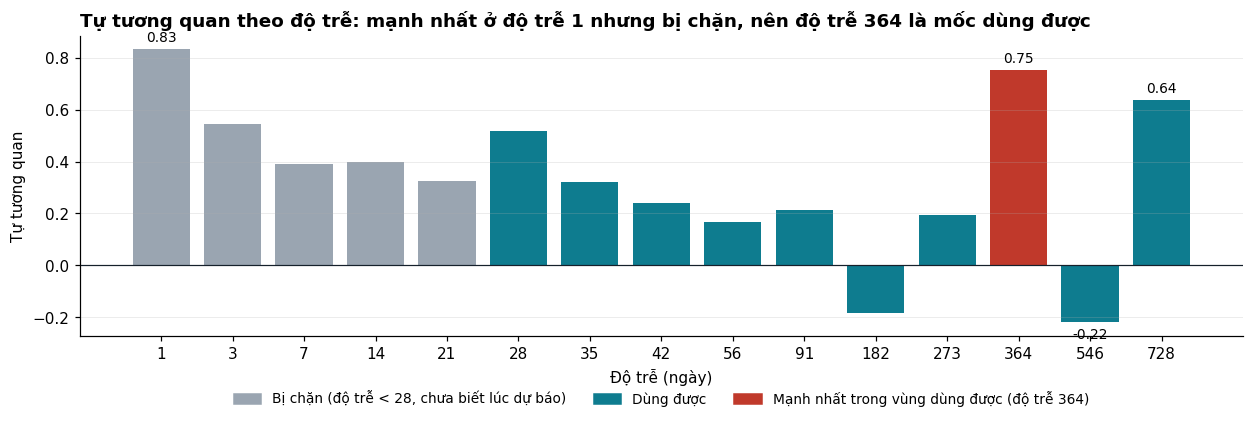

In [37]:
lag_labels = [str(l) for l in acf]
lag_colors = [C["grey"] if l < H else (C["bad"] if l == best_lag else C["accent"]) for l in acf]
fig, ax = plt.subplots(figsize=(11.5, 4))
ax.bar(lag_labels, list(acf.values()), color=lag_colors)
ax.axhline(0, color=C["ink"], lw=0.8)
for lag, v in acf.items():
    if lag in (1, best_lag, 546, 728):
        ax.text(lag_labels.index(str(lag)), v + (0.03 if v >= 0 else -0.06), f"{v:.2f}", ha="center", fontsize=9)
ax.legend(handles=[Patch(color=C["grey"], label=f"Bị chặn (độ trễ < {H}, chưa biết lúc dự báo)"),
                   Patch(color=C["accent"], label="Dùng được"),
                   Patch(color=C["bad"], label=f"Mạnh nhất trong vùng dùng được (độ trễ {best_lag})")],
          loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.14))
ax.set(xlabel="Độ trễ (ngày)", ylabel="Tự tương quan",
       title="Tự tương quan theo độ trễ: mạnh nhất ở độ trễ 1 nhưng bị chặn, nên độ trễ 364 là mốc dùng được")
ax.grid(axis="x", visible=False)
save_fig("06_tu_tuong_quan_acf")

**Đọc kết quả và quyết định**
- Tự tương quan cao nhất ở độ trễ 1 (0.833) nhưng **vô dụng**: khi dự báo trước 28 ngày ta chưa biết doanh thu hôm qua. Trong vùng được phép (từ 28 ngày trở lên), độ trễ **364** mạnh nhất với 0.751, tức "cùng ngày năm ngoái".
- Độ trễ 728 là 0.638 trong khi độ trễ 546 là -0.220. Nhịp hai năm rõ như vậy gợi ý có một chu kỳ 2 năm. Nó giải thích vì sao có cột `is_odd_year` ở nhóm lịch, và cũng là lí do cột này cần được cân nhắc cẩn thận: chuỗi chỉ dài khoảng 10 năm nên chỉ có vài chu kỳ hai năm
- **Quyết định:** nhóm đặc trưng lịch sử tập trung quanh mốc 364 ngày (cùng kỳ năm ngoái, có làm mượt) và các độ trễ từ 28 ngày trở lên 

## **Sáu quan sát và quyết định tương ứng**

In [38]:
decisions = [
    f'Mức doanh thu đứt gãy năm {break_year} nên lần cắt kiểm định rơi vào năm đó được tách riêng',
    f'Phân phối lệch phải với độ lệch {skew_raw:.3f} nên dùng log1p vf độ đo WAPE',
    f'{int(is_high.sum())} ngày cao tập trung ở cuối tháng nên giữ nguyên',
    f'Chu kỳ ngày trong tháng mạnh nhất với biên độ {cycles['ngày trong tháng']['amplitude']:.2f} lần'
    ' nên nhóm lịch cần cột đếm ngược đến cuối tháng',
    'Hiệu ứng Tết phần lớn là hiệu ứng tháng nên giữ nhóm Tết với kỳ vọng thấp',
    f'Độ trễ {best_lag} ngày là nguồn tín hiệu hợp lệ mạnh nhất nên nhóm lịch sử tập trung quanh mốc này'
]

for i, line in enumerate(decisions, 1):
    print(f'{i}. {line}')
R['decisions'] = decisions
save_results(R, '03_analyze')

1. Mức doanh thu đứt gãy năm 2019 nên lần cắt kiểm định rơi vào năm đó được tách riêng
2. Phân phối lệch phải với độ lệch 1.669 nên dùng log1p vf độ đo WAPE
3. 169 ngày cao tập trung ở cuối tháng nên giữ nguyên
4. Chu kỳ ngày trong tháng mạnh nhất với biên độ 2.84 lần nên nhóm lịch cần cột đếm ngược đến cuối tháng
5. Hiệu ứng Tết phần lớn là hiệu ứng tháng nên giữ nhóm Tết với kỳ vọng thấp
6. Độ trễ 364 ngày là nguồn tín hiệu hợp lệ mạnh nhất nên nhóm lịch sử tập trung quanh mốc này


**Đọc kết quả và quyết định: từ EDA sang thiết kế mô hình.** Bảng dưới nối mỗi quan sát với nơi nó được dùng với các mục. Đây là "sợi chỉ" xuyên suốt project: không có đặc trưng hay lựa chọn nào xuất hiện mà không có gốc rễ từ dữ liệu.

| Quan sát ở mục 4 | Được dùng ở đâu |
|---|---|
| Điểm gãy cấu trúc năm 2019 | 6.1 tách Fold 1; 7.2 giải thích bias |
| Doanh thu lệch phải | `log1p` khi huấn luyện, WAPE làm độ đo |
| Ngày cao tập trung cuối tháng | Giữ nguyên ngoại lai (5.2) |
| Mùa vụ ngày trong tháng, tháng, name | Nhóm lịch và Fourier (5.2) |
| Hiệu ứng Tết chủ yếu là hiệu ứng tháng | Nhóm Tết với kỳ vọng thấp, kiểm tra lại bằng SHAP (8) |
| ACF mạnh ở độ trễ 364 | Nhóm lịch sử: `lag_364`, cùng kỳ năm ngoái làm mượt (5.2) |

# **5. XÂY DỰNG ĐẶC TRƯNG**

- Quy tắc lùi thời gian: khi dự báo cho ngày d với khoảng dự báo H, mô hình chỉ được biết dữ liệu đến ngày d-H. Mọi đặc trưng dẫn xuất từ lịch sử biến mục tiêu đều phải lùi ít nhất H ngày.
- Cách viết an toàn: tạo trước một chuỗi nền đã lùi H ngày, rồi mọi phép rolling đều thực hiện trên chuỗi nền đó. An toàn không phải nhờ thứ tự shift và rolling mà nhờ nó khiến việc quên lùi khó xảy ra 

In [39]:
R = {}

raw = pd.read_csv(DATA / 'sales_clean.csv', parse_dates=['date']).sort_values('date')
raw = raw.reset_index(drop=True)
print(f"  Đọc {len(raw):,} dòng từ sales_clean.csv,"
      f" từ {raw.date.min().date()} đến {raw.date.max().date()}")
print(f"  Khoảng dự báo H = {H} ngày")

  Đọc 3,833 dòng từ sales_clean.csv, từ 2012-07-04 đến 2022-12-31
  Khoảng dự báo H = 28 ngày


## **5.1. Quy tắc lùi thời gian**

In [40]:
print(f"  Khi dự báo cho ngày d, mô hình chỉ được biết dữ liệu đến hết ngày d-{H}.")
print(f"  Mọi đặc trưng dẫn xuất từ lịch sử doanh thu đều phải lùi ít nhất {H} ngày.")

# minh hoạ: bốn cách viết gây rò rỉ thật, để đối chiếu với cách viết an toàn
y = raw[TARGET]
writing_styles = {
    "y.rolling(28).mean()":                        y.rolling(28).mean(),
    "y.shift(1).rolling(28).mean()":               y.shift(1).rolling(28).mean(),
    "y.shift(7).rolling(28).mean()":               y.shift(7).rolling(28).mean(),
    "y.rolling(28, center=True).mean().shift(28)": y.rolling(28, center=True).mean().shift(28),
    "y.shift(28).rolling(28).mean()  (an toàn)":   y.shift(28).rolling(28).mean(),
}

  Khi dự báo cho ngày d, mô hình chỉ được biết dữ liệu đến hết ngày d-28.
  Mọi đặc trưng dẫn xuất từ lịch sử doanh thu đều phải lùi ít nhất 28 ngày.


In [41]:
b = raw.copy()
b.loc[b.index[-(H - 1):], TARGET] *= 9.3
yb = b[TARGET]
writing_styles_broken = {
    "y.rolling(28).mean()":                        yb.rolling(28).mean(),
    "y.shift(1).rolling(28).mean()":               yb.shift(1).rolling(28).mean(),
    "y.shift(7).rolling(28).mean()":               yb.shift(7).rolling(28).mean(),
    "y.rolling(28, center=True).mean().shift(28)": yb.rolling(28, center=True).mean().shift(28),
    "y.shift(28).rolling(28).mean()  (an toàn)":   yb.shift(28).rolling(28).mean(),
}

change = pd.Series({name: abs(float(writing_styles[name].iloc[-1])
                              - float(writing_styles_broken[name].iloc[-1]))
                    for name in writing_styles})
R["writing_styles"] = change.to_dict()
print(pd.DataFrame({"phản ứng ở hàng cuối": change,
                    "kết luận": np.where(change < 1e-9, "AN TOÀN", "RÒ RỈ")})
      .to_string(float_format="{:.3e}".format))

print(f"  shift(28).rolling() cho kết quả y hệt. Thứ quyết định là độ lùi có đủ {H} không.")

                                             phản ứng ở hàng cuối kết luận
y.rolling(28).mean()                                    1.442e+07    RÒ RỈ
y.shift(1).rolling(28).mean()                           1.371e+07    RÒ RỈ
y.shift(7).rolling(28).mean()                           9.337e+06    RÒ RỈ
y.rolling(28, center=True).mean().shift(28)             5.110e+06    RÒ RỈ
y.shift(28).rolling(28).mean()  (an toàn)               0.000e+00  AN TOÀN
  shift(28).rolling() cho kết quả y hệt. Thứ quyết định là độ lùi có đủ 28 không.


**Đọc kết quả và quyết định**
- Cách "phá hoại" (nhân nhãn trong vùng bị chặn lên 9.3 lần rồi xem đặc trưng ở hàng dự báo có thay đổi không) cho thấy bốn cách viết rò rỉ đều phản ứng(thay đổi từ 5 đến 14 triệu), còn cách viết an toàn không đổi.
- Chú ý chi tiết: `shift(28).rolling()` và `rolling().shift(28)` cho kết quả y hệt. An toàn không nằm ở thứ tự hai phép mà ở việc có lùi đủ 28 ngày hay không. Việc tạo sẵn một chuỗi nền đã lùi H ngày chỉ nhằm khiến việc quên lùi khó xảy ra.
- **Quyết định:** mọi cột lịch sử được dựng trên chuỗi nền `y.shift(H)`. Cột cùng kỳ năm ngoái làm mượt dùng `shift(364 - 3).rolling(7)` để cửa sổ 7 ngày tập trung quanh d-364 mà vẫn nằm hoàn toàn ngoài vùng bị chặn. 

## **5.2. Các nhóm đặc trưng**

### **Nhóm lịch sử doanh thu.** Mọi cột đều lùi ít nhất H ngày 

- 28/364 ngày trước doanh thu bao nhiêu = lag 
- Gần đây mức doanh thu trung bình bao nhiêu = rolling_mean 
- Gần đây doanh thu dao động mạnh không = rolling std 
- Trong 91 ngày qua, mức doanh thu cao/thấp nhất = roll min/max 91 
- Khoảng 1 năm trước, mức doanh thu là bao nhiêu = smooth 
- Gần đây cao/thấp hơn mức dài hạn bao nhiêu = ratio, trend 
- Mức biến động so với quy mô doanh thu bao nhiêu = cv 

In [42]:
def add_lag_features(df, col=TARGET):
    y = df[col]
    safe = y.shift(H)

    for lag in (28, 35, 42, 56, 91, 182, 364, 371): #364: 52 x 7, 371: 53 x 7
        df[f'lag_{lag}'] = y.shift(lag)

    for w in (7, 28, 91, 364):
        df[f'roll_mean_{w}'] = safe.rolling(w, min_periods=max(2, w // 4)).mean()
        df[f'roll_std_{w}'] = safe.rolling(w, min_periods=max(2, w // 4)).std() # doanh thu biến động hay ổn định 
    df['roll_min_91'] = safe.rolling(91, min_periods=20).min()
    df['roll_max_91'] = safe.rolling(91, min_periods=20).max()

    # làm mượt: chuỗi ít "nhảy loạn" hơn để nhìn được pattern chung 
    df['lag364_smooth7'] = y.shift(364 - 3).rolling(7, min_periods=3).mean() # xung quanh thời điểm tương ứng năm trước, mức doanh thu bao nhiêu 
    df['lag364_smooth28'] = y.shift(364 - 14).rolling(28, min_periods=10).mean()

    # ti so va xu huong 
    df['ratio_28_364'] = df.roll_mean_28 / df.roll_mean_364
    df['ratio_91_364'] = df.roll_mean_91 / df.roll_mean_364
    df['trend_28_91'] = df.roll_mean_28 - df.roll_mean_91 
    df['cv_91'] = df.roll_std_91 / df.roll_mean_91 
    return df 

### **Nhóm lịch.** Ba tầng mùa vụ, đều biết trước 

- k: k chu kỳ/năm 
- fourier sin/cos: biểu diễn tính chu kỳ

In [43]:
def add_calendar_features(df):
    d = df['date']
    df['dow'] = d.dt.dayofweek
    df['dom'] = d.dt.day 
    df['month'] = d.dt.month 
    df['quarter'] = d.dt.quarter
    df['doy'] = d.dt.dayofyear
    df['days_in_month'] = d.dt.days_in_month
    df['dom_reverse'] = df.days_in_month - df.dom 
    df['is_weekend'] = (df.dow >= 5).astype('int8')
    df['is_eom'] = (df.dom_reverse <= 3).astype('int8')
    df['is_som'] = (df.dom <= 2).astype('int8')
    df['is_odd_year'] = (d.dt.year % 2).astype('int8')
    for k in (1, 2, 3, 4):
        df[f'fourier_sin{k}'] = np.sin(2 * np.pi * k * df.doy / 365.25)
        df[f'fourier_cos{k}'] = np.cos(2 * np.pi * k * df.doy / 365.25)
    return df 

### **Nhóm Tết và ngày đặc biệt.** Ngày âm lịch trượt nên phải tra bảng 

In [44]:
def add_tet_features(df):
    d = df['date']
    tet = pd.to_datetime(pd.Series(TET_DATES))
    diff = np.stack([(d - t).dt.days.values for t in tet])
    df['days_to_tet'] = diff[np.abs(diff).argmin(axis=0), np.arange(len(df))]
    df['tet_before'] = df.days_to_tet.between(-30, -1).astype('int8')
    df['tet_after'] = df.days_to_tet.between(0, 14).astype('int8')
    sp = set(RETAIL_SPECIAL_DAYS)
    df['is_special_day'] = np.array([(m, dd) in sp for m, dd in zip(d.dt.month, d.dt.day)], dtype='int8')

    return df 

### **Nhóm khuyến mãi.** Lịch công bố trước nên dùng được cho cả ngày dự báo

In [45]:
def add_promo_features(df):
    pr = pd.read_csv(DATA / 'promotions.csv', parse_dates=['start_date', 'end_date'])
    df['promo_n'], df['promo_disc_max'], df['promo_day_idx'] = 0, 0.0, -1 
    df['promo_streetwear'], df['promo_outdoor'] = 0, 0 
    for _, p in pr.iterrows():
        m = (df.date >= p.start_date) & (df.date <= p.end_date)
        if not m.any():
            continue
        df.loc[m, 'promo_n'] += 1 
        df.loc[m, 'promo_disc_max'] = np.maximum(df.loc[m, 'promo_disc_max'],
                                                 float(p.discount_value))

        # hai chương trình có thể chồng ngày lên nhau: giữ chương trình mới bắt đầu,
        # nếu không kết quả sẽ phụ thuộc thứ tự dòng trong csv 
        idx = (df.loc[m, 'date'] - p.start_date).dt.days 
        cur = df.loc[m, 'promo_day_idx']
        df.loc[m, 'promo_day_idx'] = np.where(cur < 0, idx, np.minimum(cur, idx))
        if p.applicable_category == 'Streetwear':
            df.loc[m, 'promo_streetwear'] = 1
        elif p.applicable_category == 'Outdoor':
            df.loc[m, 'promo_outdoor'] = 1

        df['promo_any'] = (df.promo_n > 0).astype('int8')
    return df 

In [46]:
df = add_promo_features(add_tet_features(add_calendar_features(add_lag_features(raw.copy()))))
features = [c for c in df.columns if c not in ('date', TARGET, 'cogs')]

GROUPS = {
    'lịch sử doanh thu': ('lag', 'roll', 'ratio', 'trend', 'cv_'),
    'lịch': ('dow', 'dom', 'month', 'quarter', 'doy', 'year', 'days_in', 'is_week',
             'is_eom', 'is_som', 'is_odd', 'fourier'),
    'Tết và ngày đặc biệt': ('tet_', 'days_to_tet', 'is_special'),
    'khuyến mãi': ('promo', 'has_promo'),
}
R['groups'] = {}

for name, prefix in GROUPS.items():
    columns = [c for c in features if c.startswith(prefix)]
    R['groups'][name] = {'n_columns': len(columns), 'columns': columns}
    print(f'{name:24s} {len(columns):3d} cột   {', '.join(columns)} ...')
R['n_features'] = len(features)
print(f"  {'TỔNG':24s} {len(features):3d} cột")
assert sum(v["n_columns"] for v in R["groups"].values()) == len(features), "có cột lọt nhóm"

lịch sử doanh thu         24 cột   lag_28, lag_35, lag_42, lag_56, lag_91, lag_182, lag_364, lag_371, roll_mean_7, roll_std_7, roll_mean_28, roll_std_28, roll_mean_91, roll_std_91, roll_mean_364, roll_std_364, roll_min_91, roll_max_91, lag364_smooth7, lag364_smooth28, ratio_28_364, ratio_91_364, trend_28_91, cv_91 ...
lịch                      19 cột   dow, dom, month, quarter, doy, days_in_month, dom_reverse, is_weekend, is_eom, is_som, is_odd_year, fourier_sin1, fourier_cos1, fourier_sin2, fourier_cos2, fourier_sin3, fourier_cos3, fourier_sin4, fourier_cos4 ...
Tết và ngày đặc biệt       4 cột   days_to_tet, tet_before, tet_after, is_special_day ...
khuyến mãi                 6 cột   promo_n, promo_disc_max, promo_day_idx, promo_streetwear, promo_outdoor, promo_any ...
  TỔNG                      53 cột


## **5.3. Kiểm tra rò rỉ dữ liệu**

**Bối cảnh và mục tiêu:** Mục 5.1 đã chứng minh cách viết an toàn ở một chuỗi minh họa. Mục này kiểm tra toàn bộ pipeline đặc trưng thật bằng hai phép thử bổ sung nhau: (1) phép thử phá hoại trên mọi cột lịch sử; (2) một thí nghiệm cho thấy rò rỉ trông như thế nào khi nó lọt vào, để người đọc biết cảnh báo cần nhìn vào đâu. 

**Phép thử phá hoại.** Đổi nhãn trong vùng bị chặn rồi xem đặc trưng có động không 

In [47]:
def leakage_probe(raw, n_checks=8):
    """ Phép thử phá hoại

    Cố tình phá dữ liệu target Revenue ở một vùng mà feature không được phép nhìn
    thấy, rồi kiểm tra xem các feature có thay đổi hay không. Nếu thay đổi -> leakage
    """
    fa = add_lag_features(raw.copy())
    cols = [c for c in fa.columns if c.startswith(('lag', 'roll', 'ratio', 'trend', 'cv_'))]
    rows = np.linspace(max(H, 400), len(raw) - 1, n_checks, dtype=int)
    worst = 0.0 
    for row in rows:
        b = raw.copy()
        b.loc[b.index[row - H + 1: row + 1], TARGET] *= 9.3 
        fb = add_lag_features(b)
        worst = max(worst, float((fa[cols].iloc[row].fillna(-1)
                                  - fb[cols].iloc[row].fillna(-1)).abs().max()))
    return worst, len(rows), len(cols) 

worst, n_checkpoints, n_columns = leakage_probe(raw)
R['probe'] = {'max_change': worst, 'n_checkpoints': n_checkpoints,
              'n_columns': n_columns}
print(f'Phá hoại {H} nhãn gần nhất tại {n_checkpoints} mốc thời gian,'
      f' kiểm {n_columns} cột')
print(f'Thay đổi lớn nhất quan sát được = {worst:.3e}')
assert worst < 1e-9, "RÒ RỈ: có đặc trưng nhìn thấy nhãn trong vùng bị chặn"

Phá hoại 28 nhãn gần nhất tại 8 mốc thời gian, kiểm 24 cột
Thay đổi lớn nhất quan sát được = 0.000e+00


In [48]:
# điểm số khi rò rỉ 
ready = df.dropna(subset=["lag_371", "roll_mean_364"]).reset_index(drop=True)
ready.to_csv(DATA / f"features_h{H}.csv", index=False)
ready = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
train, test = split_by_date(ready, TEST_FOLD[1], TEST_FOLD[2], TEST_FOLD[3])
y_train_log = np.log1p(train[TARGET].values)
y_test = test[TARGET].values

In [49]:
# huấn luyện hai lần, chỉ khác một cột 
clean_model = get_models()['LightGBM']
clean_model.fit(train[features], y_train_log)
m_clean = metrics(y_test, np.expm1(clean_model.predict(test[features])))

leaked_features = features + ['cogs']
leaked_model = get_models()['LightGBM']
leaked_model.fit(train[leaked_features], y_train_log)
m_leaked = metrics(y_test, np.expm1(leaked_model.predict(test[leaked_features])))

In [ ]:
importance = pd.Series(leaked_model.feature_importances_,
                       index=leaked_features).sort_values(ascending=False)
cogs_correlation = float(df[TARGET].corr(df['cogs']))
R['leak_demo'] = {'clean': m_clean, 'leaked': m_leaked,
                  'cogs_correlation': cogs_correlation,
                  'top5_importance': {k: int(v) for k, v in importance.head(5).items()}}

print(f'\n Nếu để rò rỉ lọt vào thì điểm số trông như thế nào: huấn luyện LightGBM'
      f' hai lần')
print(f'   trên phần train của {TEST_FOLD[0]}, chỉ khác nhau ở cột cogs cùng ngày.')
print(f'   Tương quan giữa cogs và {TARGET} cùng ngày = {cogs_correlation:.4f}')
print(pd.DataFrame({f'{len(features)} đặc trưng hợp lệ': m_clean,
                    'thêm cogs cùng ngày (rò rỉ)': m_leaked}).T.round(4)
                    .rename_axis('bộ đặc trưng').to_string())
print('\n  Thứ hạng quan trọng của 5 cột đầu ở mô hình có rò rỉ: '
      + ', '.join(f'{k}={v}' for k, v in importance.head(5).items()))
print(f'\n  R2 nhảy từ {m_clean['R2']:.4f} lên {m_leaked['R2']:.4f} còn WAPE giảm từ'
      f' {m_clean['WAPE']:.4f} xuống {m_leaked['WAPE']:.4f}')
print(' Trong bài toán dự báo, R2 gần 1 kèm một cột chỉ biết được sau khi bán xong '
      'là dấu hiệu rò rỉ, không phải mô hình tốt.')


 Nếu để rò rỉ lọt vào thì điểm số trông như thế nào: huấn luyện LightGBM hai lần
   trên phần train của TEST, chỉ khác nhau ở cột cogs cùng ngày.
   Tương quan giữa cogs và revenue cùng ngày = 0.9760
                               WAPE    bias      R2
bộ đặc trưng                                       
53 đặc trưng hợp lệ          0.2154 -0.1431  0.6351
thêm cogs cùng ngày (rò rỉ)  0.0278  0.0072  0.9954

  Thứ hạng quan trọng của 5 cột đầu ở mô hình có rò rỉ: cogs=2812, lag_364=1360, lag_28=1070, lag364_smooth7=819, lag_371=782

  R2 nhảy từ 0.6351 lên 0.9954 còn WAPE giảm từ 0.2154 xuống 0.0278
   Trong bài toán dự báo, R2 gần 1 kèm một cột chỉ biết được sau khi bán xong là dấu hiệu rò rỉ, không phải mô hình tốt.


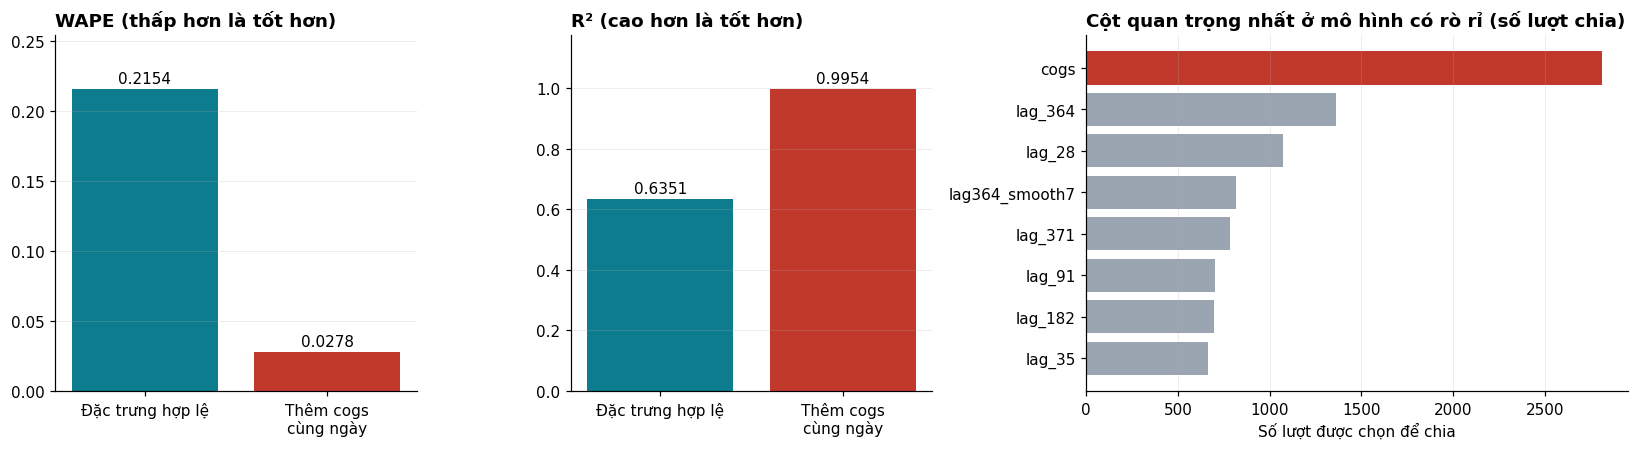

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={"width_ratios": [1, 1, 1.5]})
for ax, key, title in ((axes[0], "WAPE", "WAPE (thấp hơn là tốt hơn)"), (axes[1], "R2", "R² (cao hơn là tốt hơn)")):
    vals = [m_clean[key], m_leaked[key]]
    bars = ax.bar(["Đặc trưng hợp lệ", "Thêm cogs\ncùng ngày"], vals, color=[C["accent"], C["bad"]])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.02, f"{v:.4f}", ha="center", fontsize=10)
    ax.set(title=title, ylim=(0, max(vals) * 1.18))
    ax.grid(axis="x", visible=False)
top = importance.head(8)[::-1]
axes[2].barh(top.index, top.values, color=[C["bad"] if n == "cogs" else C["grey"] for n in top.index])
axes[2].set(title="Cột quan trọng nhất ở mô hình có rò rỉ (số lượt chia)", xlabel="Số lượt được chọn để chia")
axes[2].grid(axis="y", visible=False)
save_fig("07_thi_nghiem_ro_ri_cogs")

**Đọc kết quả và quyết định**
- Chỉ thêm một cột `cogs`, R2 nhảy từ 0.64 lên 0.99 và WAPE từ **0.2038 xuống 0.0285**. Ngay lập tức `cogs` leo lên đầu bảng độ quan trọng
- Điểm số đó là giả: thực tế ta không có `cogs` của ngày cần dự báo. Bài học tổng quát: **điểm số đẹp bất thường không phải tin vui mà là lý do để truy tìm rò rỉ**. Thí nghiệm là cũng là bằng chứng cho quyết định loại `cogs` ở mục 4. 

## **5.4. Giai đoạn khởi động** 

In [52]:
n_before = len(df)
df = df.dropna(subset=['lag_371', 'roll_mean_364']).reset_index(drop=True)
R['warmup'] = {'dropped': n_before - len(df), 'remaining': len(df),
               'from': str(df.date.min().date()), 'to': str(df.date.max().date()),
               'loss_pct': float(100 * (n_before - len(df)) / n_before)}
print(f'Bỏ {n_before - len(df)} ngày đầu chuỗi'
      f'({R['warmup']['loss_pct']:.1f}%) vì thiếu lag_371')
print(f'Còn {len(df):,} ngày, từ {df.date.min().date()} đến {df.date.max().date()}')
print(f'Đánh đổi: mất {R['warmup']['loss_pct']:.1f}% chuỗi để có đặc trưng cùng kỳ năm trước')
df.to_csv(DATA / f'features_h{H}.csv', index=False)
R['features'] = features
save_results(R, '04_features')

Bỏ 371 ngày đầu chuỗi(9.7%) vì thiếu lag_371
Còn 3,462 ngày, từ 2013-07-10 đến 2022-12-31
Đánh đổi: mất 9.7% chuỗi để có đặc trưng cùng kỳ năm trước


**Đọc kết quả và quyết định**
- Cột `lag_371` cần 371 ngày lịch sử nên **9.7% chuỗi (371 ngày đầu) bị bỏ**, còn 3462 ngày từ 2013-07-10 đến 2022-12-31. Đây là một đánh đổi có chủ đích: chấp nhận mất 10% dữ liệu để có các đặc trưng cùng kỳ năm trước, vốn là tín hiệu mạnh nhất (ACF).
- Cần nhớ rằng phần dữ liệu bị bỏ chỉ mất ở vai trò hàng huấn luyện, nó vẫn được dùng để tính các đặc trưng lịch sử cho các hàng sau.
- **Quyết định và bàn giao cho Mục 6:** từ đây, mọi mô hình đều đọc cùng một bảng đặc trưng từ `tệp features_h28.csv`

# **6. XÂY DỰNG MÔ HÌNH**

Năm mục con theo đúng thứ tự phải làm 
1. chia tập theo thời gian 
2. chọn độ đo 
3. mô hình cơ sở 
4. huấn luyện các mô hình cây 
5. hiệu quả của các nhóm đặc trưng 

- Ba mục đầu phải xong trước khi chạy mô hình đầu tiên
- Kỷ luật xuyên suốt: mọi lựa chọn đều được quyết định bằng kiểm định chéo. cột TEST có xuất hiện trong vài bảng nhưng chỉ để đối chiếu, không có quyết định nào dựa vào nó 

In [53]:
warnings.filterwarnings('ignore')
R = {}

df = pd.read_csv(DATA / f'features_h{H}.csv', parse_dates=['date'])
features = load_results('04_features')['features']
series = df.set_index('date').revenue

CV_FOLDS = ['Fold 2', 'Fold 3']

def evaluate_fold(fold, columns, model=None):
    train, valid = split_by_date(df, fold[1], fold[2], fold[3])
    if model is None:
        model = get_models()['LightGBM']

    model.fit(train[columns], np.log1p(train.revenue.values))
    prediction = np.expm1(model.predict(valid[columns])) # model đang dự đoán trên log scale nên phải biến ngược thành revenue ban đầu 
    return metrics(valid.revenue.values, prediction)

def cross_validate(columns, model_name='LightGBM'):
    scores = {}
    for fold in FOLDS:
        model = get_models()[model_name]
        scores[fold[0]] = evaluate_fold(fold, columns, model)['WAPE']

    scores['CV'] = float(np.mean([scores[f] for f in CV_FOLDS]))
    return scores

## **6.1. Chia tập theo thời gian**

**Bối cảnh và mục tiêu:** Chuỗi thời gian có thứ tự, nên không được xáo trộn khi chia tập: tập huấn luyện phải nằm trước tập kiểm định. Dùng gốc trượt (rolling origin): lần lượt lùi ngày cắt về các năm 2019, 2020, 2021 rồi 2022, mỗi lần dự báo nửa cuối năm (tháng 7 đến tháng 12, 184 ngày). Như vậy mô hình được thử trên nhiều giai đoạn khác nhau thay vì chỉ một, và mỗi lần chỉ dùng dữ liệu có sẵn tại thời điểm đó

**Hai chi tiết thiết kế:** (1) khoảng đệm 31 ngày (trọn tháng 6) giữa cuối tập huấn luyện và đầu tập kiểm định; (2) Fold 1 tách riêng vì rơi đúng vào điểm gãy 2019

In [54]:
R['folds'] = []
for name, train_end, valid_start, valid_end in FOLDS + [TEST_FOLD]:
    train, valid = split_by_date(df, train_end, valid_start, valid_end)
    R['folds'].append({
        'name': name,
        'train_end': train_end,
        'valid': f'{valid_start} đến {valid_end}',
        'n_train': len(train), 'n_valid': len(valid),
        'buffer_days': (pd.Timestamp(valid_start) - pd.Timestamp(train_end)).days
    })
print(pd.DataFrame(R['folds']).to_string(index=False))
buffer_days = R['folds'][0]['buffer_days']

print(f"\n  Khoảng đệm {buffer_days} ngày, dài hơn khoảng dự báo H = {H}. Cần đệm vì hàng")
print(f"  huấn luyện ở ngày T mang nhãn là doanh thu ngày T, trong khi hàng kiểm định")
print(f"  đầu tiên chỉ được biết dữ liệu tới T trừ {H}.")
print(f"\n  Lần cắt thứ nhất rơi trúng năm mức doanh thu đứt gãy nên được tách riêng.")
print(f"  Con số kiểm định chéo lấy trung bình hai lần cắt còn lại.")

  name  train_end                     valid  n_train  n_valid  buffer_days
Fold 1 2019-05-31 2019-07-31 đến 2019-12-31     2152      154           61
Fold 2 2020-05-31 2020-07-31 đến 2020-12-31     2518      154           61
Fold 3 2021-05-31 2021-07-31 đến 2021-12-31     2883      154           61
  TEST 2022-05-31 2022-07-31 đến 2022-12-31     3248      154           61

  Khoảng đệm 61 ngày, dài hơn khoảng dự báo H = 28. Cần đệm vì hàng
  huấn luyện ở ngày T mang nhãn là doanh thu ngày T, trong khi hàng kiểm định
  đầu tiên chỉ được biết dữ liệu tới T trừ 28.

  Lần cắt thứ nhất rơi trúng năm mức doanh thu đứt gãy nên được tách riêng.
  Con số kiểm định chéo lấy trung bình hai lần cắt còn lại.


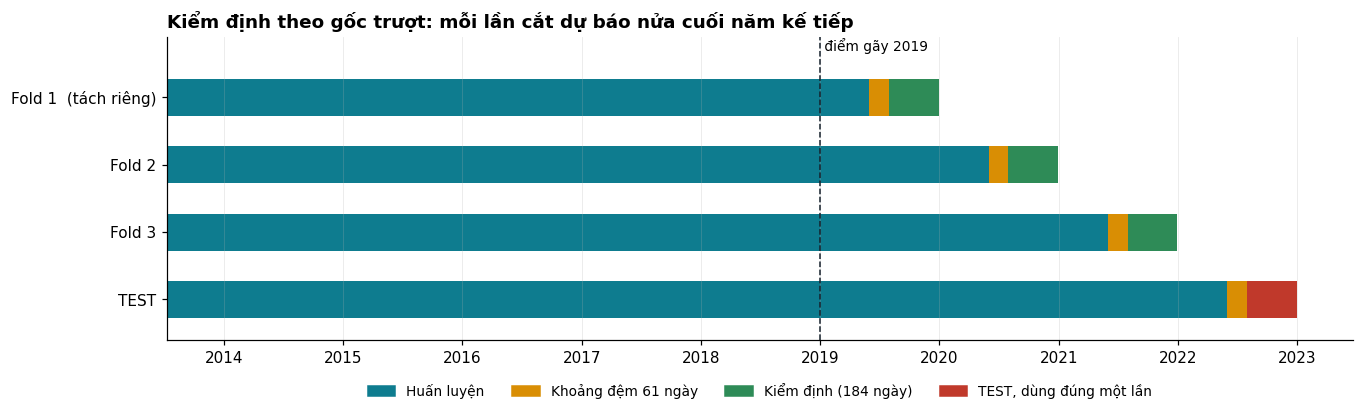

In [55]:
# Hình: sơ đồ chia tập theo thời gian (xanh = huấn luyện, cam = khoảng đệm, xanh lá = kiểm định, đỏ = TEST)
splits = FOLDS + [TEST_FOLD]
first_day = mdates.date2num(df.date.min())
fig, ax = plt.subplots(figsize=(12.5, 3.9))
for row, (name, train_end, v_start, v_end) in enumerate(splits):
    y_pos = len(splits) - 1 - row
    t_end, v0, v1 = (mdates.date2num(pd.Timestamp(x)) for x in (train_end, v_start, v_end))
    ax.barh(y_pos, t_end - first_day, left=first_day, height=0.55, color=C["accent"])
    ax.barh(y_pos, v0 - t_end, left=t_end, height=0.55, color=C["warn"])
    ax.barh(y_pos, v1 - v0, left=v0, height=0.55, color=C["bad"] if name == "TEST" else C["good"])
ax.axvline(mdates.date2num(pd.Timestamp("2019-01-01")), color=C["ink"], ls="--", lw=1)
ax.text(mdates.date2num(pd.Timestamp("2019-01-01")), len(splits) - 0.35, " điểm gãy 2019", fontsize=9, va="bottom")
labels = [f"{s[0]}" + ("  (tách riêng)" if s[0] == "Fold 1" else "") for s in splits][::-1]
ax.set_yticks(range(len(splits))); ax.set_yticklabels(labels)
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(-0.6, len(splits) - 0.1)
ax.legend(handles=[Patch(color=C["accent"], label="Huấn luyện"), Patch(color=C["warn"], label=f"Khoảng đệm {buffer_days} ngày"),
                   Patch(color=C["good"], label="Kiểm định (184 ngày)"), Patch(color=C["bad"], label="TEST, dùng đúng một lần")],
          loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.1))
ax.set(title="Kiểm định theo gốc trượt: mỗi lần cắt dự báo nửa cuối năm kế tiếp")
ax.grid(axis="y", visible=False)
save_fig("08_so_do_chia_tap")

## **6.2. Chọn độ đo**

**Bối cảnh và mục tiêu:** Chọn độ đo trước khi thấy kết quả để không bị cám dỗ chọn cái làm đẹp mô hình. Ba lựa chọn và lí do:

- **WAPE** làm độ đo chính. Tính trên tổng nên ổn định, dễ giải thích (sai lệch bằng bao nhiêu phần trăm doanh thu). Không dùng RMSE vì phân phối lệch phải; không dùng MAPE vì chia cho từng ngày nen phóng đại sai số ở ngày doanh thu thấp.
- **Bias = (trung bình dự báo - trung bình thực tế) / trung bình thực tế** luôn đi kèm, vì WAPE không nhìn thấy thiên lệch: một mô hình dự báo thấp đều 15% mỗi ngày và một mô hình sai ngẫu nhiên có thể cho cùng WAPE.
- **R2** phụ, để so với các báo cáo khác.

Mô hình huấn luyện trên `log1p(revenue)`, dự báo xong đổi ngược bằng `expm1`, kẹp giá trị không âm, và mọi độ đo tính trên thang gốc.

## **6.3. Mô hình cơ sở**

In [56]:
level_ratio = (series.shift(H).rolling(91).mean() / series.shift(364+H).rolling(91).mean())

BASELINES = {
    'y[d-28]': series.shift(H),
     'trung bình 7 ngày, lùi 28': series.shift(H).rolling(7).mean(),
     'trung bình 28 ngày, lùi 28': series.shift(H).rolling(28).mean(),
     'cùng kỳ năm trước y[d-364]': series.shift(364),
     'cùng kỳ hai năm trước y[d-728]': series.shift(728),
     'trung bình hai năm cùng kỳ': (series.shift(364) + series.shift(728)) / 2,
     'cùng kỳ năm trước nhân hệ số mức': series.shift(364) * level_ratio
}

### **Đo từng mô hình cơ sở trên mọi lần cắt**

In [57]:
rows = []
for name, prediction in BASELINES.items():
    row = {'baseline': name}
    for fold in FOLDS + [TEST_FOLD]:
        _, valid = split_by_date(df, fold[1], fold[2], fold[3])
        p = np.nan_to_num(prediction.reindex(valid.date).values)
        row[fold[0]] = metrics(valid.revenue.values, p)['WAPE']
    row['CV'] = float(np.mean([row[f] for f in CV_FOLDS]))
    rows.append(row)

table = pd.DataFrame(rows).set_index('baseline')
columns_shown = ['Fold 1', 'Fold 2', 'Fold 3', 'CV', 'TEST']
print(table[columns_shown].round(4).rename_axis('mô hình cơ sở').to_string())

                                  Fold 1  Fold 2  Fold 3      CV    TEST
mô hình cơ sở                                                           
y[d-28]                           0.4181  0.4098  0.4635  0.4367  0.3910
trung bình 7 ngày, lùi 28         0.3535  0.3733  0.3406  0.3570  0.3315
trung bình 28 ngày, lùi 28        0.4343  0.4475  0.4130  0.4303  0.4019
cùng kỳ năm trước y[d-364]        0.6305  0.3473  0.4188  0.3831  0.2986
cùng kỳ hai năm trước y[d-728]    0.6889  0.5974  0.4503  0.5239  0.2776
trung bình hai năm cùng kỳ        0.6448  0.3832  0.3872  0.3852  0.2329
cùng kỳ năm trước nhân hệ số mức  0.3104  0.3854  0.4601  0.4227  0.3176


### **Chọn mô hình cơ sở bằng kiểm định chéo**

In [58]:
best_by_cv = table['CV'].idxmin()
best_by_test = table['TEST'].idxmin()
R['baselines'] = table[columns_shown].to_dict('index')
R['baseline_chosen'] = {'name': best_by_cv,
                        'WAPE_cv': float(table.loc[best_by_cv, 'CV']),
                        'WAPE_test': float(table.loc[best_by_cv, 'TEST'])}
R['baseline_trap'] = {'best_by_test': best_by_test,
                      "WAPE_test": float(table.loc[best_by_test, "TEST"]),
                      "WAPE_cv": float(table.loc[best_by_test, "CV"]),
                      "best_by_cv": best_by_cv}
print(f"\n  Chọn theo kiểm định chéo: {best_by_cv}")
print(f"    CV = {table.loc[best_by_cv, 'CV']:.4f}   TEST = {table.loc[best_by_cv, 'TEST']:.4f}")
if best_by_test != best_by_cv:
    print(f'\n Nếu chọn theo tập kiểm tra thì mô hình cơ sở tốt nhất là {best_by_test}')
    print(f'   TEST = {table.loc[best_by_test, 'TEST']:.4f}'
    f" nhưng CV chỉ {table.loc[best_by_test, 'CV']:.4f}")
    print("  Chọn theo tập kiểm tra là chọn theo may mắn trên"
      " một cửa sổ chứ không phải quy luật.")



  Chọn theo kiểm định chéo: trung bình 7 ngày, lùi 28
    CV = 0.3570   TEST = 0.3315

 Nếu chọn theo tập kiểm tra thì mô hình cơ sở tốt nhất là trung bình hai năm cùng kỳ
   TEST = 0.2329 nhưng CV chỉ 0.3852
  Chọn theo tập kiểm tra là chọn theo may mắn trên một cửa sổ chứ không phải quy luật.


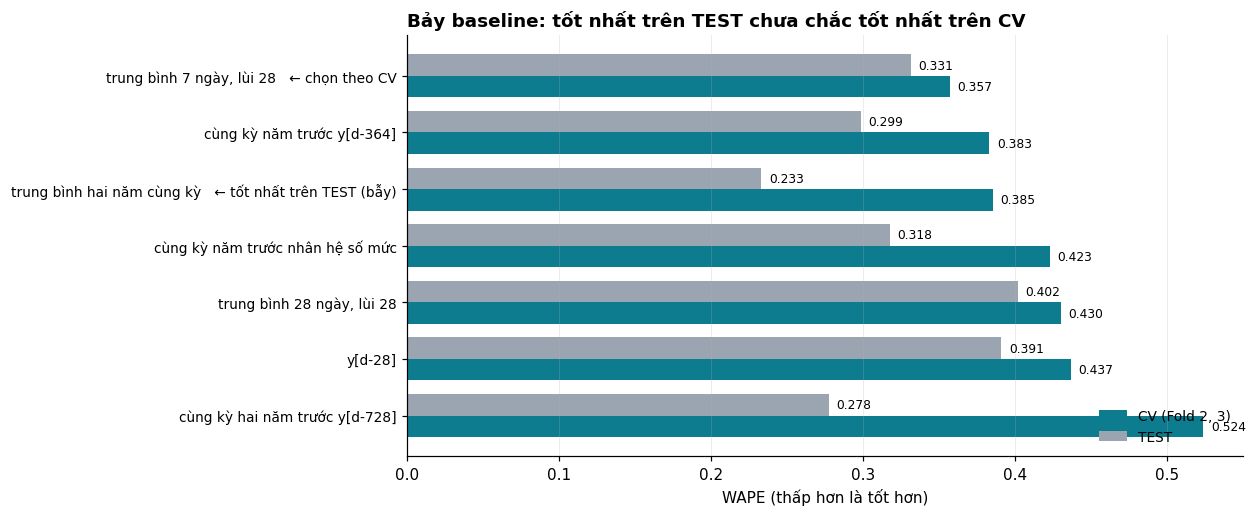

In [59]:
# Hình: WAPE của bảy baseline trên CV và TEST. Đánh dấu baseline được chọn theo CV và baseline "may mắn" trên TEST.
plot_table = table[["CV", "TEST"]].sort_values("CV", ascending=False)
y_pos, bar_h = np.arange(len(plot_table)), 0.38
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.barh(y_pos - bar_h / 2, plot_table.CV, bar_h, color=C["accent"], label="CV (Fold 2, 3)")
ax.barh(y_pos + bar_h / 2, plot_table.TEST, bar_h, color=C["grey"], label="TEST")
ax.set_yticks(y_pos)
ax.set_yticklabels([n + ("   ← chọn theo CV" if n == best_by_cv else "   ← tốt nhất trên TEST (bẫy)" if n == best_by_test else "")
                    for n in plot_table.index], fontsize=9)
for i, (cv_, te_) in enumerate(zip(plot_table.CV, plot_table.TEST)):
    ax.text(cv_ + 0.005, i - bar_h / 2, f"{cv_:.3f}", va="center", fontsize=8)
    ax.text(te_ + 0.005, i + bar_h / 2, f"{te_:.3f}", va="center", fontsize=8)
ax.set(xlabel="WAPE (thấp hơn là tốt hơn)", title="Bảy baseline: tốt nhất trên TEST chưa chắc tốt nhất trên CV")
ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
save_fig("09_baseline_cv_va_test")

**Đọc kết quả và quyết định**

- Baseline mạnh nhất theo CV là **"trung bình 7 ngày, lùi 28**: CV 0.3570, TEST 0.3315.
- Nếu nhìn TEST thì "trung bình hai năm cùng kỳ" thắng với 0.2329, nhưng CV của nó chỉ 0.3852, kém hẳn baseline đã chọn. TEST chỉ là một cửa sổ, trùng hợp với giai đoạn mà hai năm trước có mức tương tự. Chọn theo TEST là chọn theo may mắn.
- Một quan sát khác: baseline y[d-728] rất kém ở Fold 1 và Fold 2 (0.69 và 0.6) vì điểm gãy 2019 làm mức hai năm trước quá khác, nhưng lại tốt ở TEST (0.2776). Cùng một quy tắc, hiệu quả phụ thuộc hoàn toàn vào việc mức doanh thu có ổn định hay không.
- **Quyết định:** baseline chính thức là trung bình 7 ngày, lùi 28 với **TEST WAPE 0.3315 là mốc mô hình máy phải thắng**. Mọi phần trăm cải thiện ở mục 7 đều tính so với con số này.

## **6.4. Huấn luyện các mô hình cây**

In [60]:
records = []
for fold in FOLDS:
    for model_name, model in get_models().items():
        started = time.time()
        score = evaluate_fold(fold, features, model)
        records.append(dict(fold=fold[0], model=model_name,
                            fit_seconds=time.time() - started, **score))
cv_table = pd.DataFrame(records)

### **Gộp hai lần cắt ổn định**

In [61]:
stable = (cv_table[cv_table.fold.isin(CV_FOLDS)]
          .groupby('model')
          .agg(WAPE=('WAPE', 'mean'), bias=('bias', 'mean'),
               fit_seconds=('fit_seconds', 'mean')).sort_values('WAPE'))

fold1 = cv_table[cv_table.fold == 'Fold 1'].set_index('model')

summary = stable.assign(fold1_WAPE=fold1.WAPE, fold1_bias=fold1.bias)
print(summary.round(4)
      .rename(columns={'WAPE': 'CV WAPE', 'bias': 'CV bias', 'fit_seconds': 'giây',
                       'fold1_WAPE': 'Fold 1 WAPE', 'fold1_bias': 'Fold 1 bias'})
      .rename_axis('mô hình').to_string())

chosen_model = stable.index[0]
R['cv'] = summary.to_dict('index')
R['chosen_model'] = chosen_model

print(f"\n  Tốt nhất theo kiểm định chéo: {chosen_model} với WAPE {stable.WAPE.iloc[0]:.4f}")
print(f"  Lần cắt thứ nhất cho WAPE {fold1.loc[chosen_model, 'WAPE']:.4f}"
      f" và thiên lệch {fold1.loc[chosen_model, 'bias']:+.3f}, lệch hẳn khỏi hai lần còn lại")

slow = float(stable.loc['GradientBoosting', 'fit_seconds'])
fast = float(stable.loc['LightGBM', 'fit_seconds'])
R['histogram_speedup'] = slow / fast 
print(f"\n  Thuật toán histogram: LightGBM {fast:.1f} giây so với GradientBoosting"
      f" {slow:.1f} giây, nhanh gấp {slow / fast:.1f} lần")

                  CV WAPE  CV bias     giây  Fold 1 WAPE  Fold 1 bias
mô hình                                                              
GradientBoosting   0.2521  -0.0830  20.4459       0.4172       0.3640
XGBoost            0.2596  -0.0476   5.7721       0.4498       0.4302
LightGBM           0.2612  -0.0705   7.0855       0.4416       0.4339
RandomForest       0.2710  -0.0771   5.6870       0.4652       0.4432
DecisionTree       0.3305  -0.1190   0.0884       0.5702       0.5259

  Tốt nhất theo kiểm định chéo: GradientBoosting với WAPE 0.2521
  Lần cắt thứ nhất cho WAPE 0.4172 và thiên lệch +0.364, lệch hẳn khỏi hai lần còn lại

  Thuật toán histogram: LightGBM 7.1 giây so với GradientBoosting 20.4 giây, nhanh gấp 2.9 lần


**Đọc kết quả và quyết định**

1. **Xếp hạng theo CV WAPE:** Cây đơn thường kém nhất, các mô hình boosting và RandomForest sát nhau. Khi ba mô hình dẫn đầu chỉ kém vài phần trăm tương đối trên chỉ hai lần cắt, khác biệt đó **nằm trong vùng nhiễu**: không nên kết luận "mô hình A tốt hơn hẳn mô hình B""
2. **Bias Fold 1 dương lớn:** (mọi mô hình dự báo cao vọt). Đây là hệ quả của điểm gãy 2019: cây quyết định chỉ dự báo quanh những mức đã thấy khi huấn luyện, nên không tự hạ mức khi doanh thu giảm đột ngột. Đây là điểm yếu của mô hình cây, không riêng mô hình nào.
3. **Thời gian huấn luyện:** LightGBM nhanh hơn GradientBoosting nhiều lần nhờ thuật toán histogram (gom giá trị liên tục vào các thùng rời rạc nên tìm điểm chia rẻ hơn). Đây là lý do LightGBM là lựa chọn thực dụng khi cần thử nhiều cấu hình, và nó cũng là điều kiện để tinh chỉnh ngay sau đây khả thi.

**Quyết định:** hai mô hình boosting nhanh nhất (LightGBM, XGBoost) được đưa vào tinh chỉnh ở 6.4. Ba mô hình còn lại giữ cấu hình gốc làm mốc tham chiếu.

## **6.4b. Tinh chỉnh siêu tham số**

**Bối cảnh và mục tiêu.** Cấu hình gốc (`n_estimators=700, learning_rate=0.04, num_leaves=31...`) là chọn tay, không có căn cứ dữ liệu. Ta không biết nó tốt hay chỉ "chưa tệ". Mục này thay việc chọn tay bằng một quy trình có thể giải thích được

**Cách làm**

1. **Tìm kiếm Bayes bằng Optuna (TPE)** thay vì lưới cố định: mỗi lần thử học từ các lần trước để chọn điểm tiếp theo, hiệu quả hơn tìm kiếm ngẫu nhiên khi danh sách nhỏ.
2. **Hàm mục tiêu = WAPE trung bình trên Fold 2 và Fold 3**, đúng bằng định nghĩa CV đã dùng xuyên suốt. Dùng cùng một thước đo để kết quả tinh chỉnh so sánh được với các mô hình khác.
3. **Early stopping** quyết định số cây nên `n_estimators` không còn là siêu tham số phải đoán.
4. **Lần thử số 0 là cấu hình gốc** (cộng early stopping). Nhờ vậy tách được hai nguồn cải thiện: đến từ early stopping hay đến từ tìm kiếm siêu tham số.
5. **Không gian tìm kiếm vừa phải và có chính quy hóa** (`reg_lambda, reg_alpha, min_child_samples/min_child_weight, gamma`) để hạn chế quá khớp vào hai lần cắt CV.

**Ba rủi ro cần kiếm soát, và các xử lý:**

| Rủi ro | Cách xử lý |
|---|---|
| Rò rỉ qua early stopping | Chỉ dùng đuôi 91 ngày *của tập huấn luyện* để dừng sớm; không bao giờ nhìn tập kiểm định hay TEST |
| Quá khớp vào CV (40 lần thử × 2 lần cắt) | Điểm CV của cấu hình tốt nhất là **lạc quan** (được chọn *vì* điểm cao trên chính các lần cắt này). Vì vậy đánh giá thật là **Fold 1** (không tham gia tinh chỉnh) và **TEST** |
| So sánh không công bằng giữa mô hình đã và chưa tinh chỉnh | Chỉ tinh chỉnh hai mô hình boosting với **cùng ngân sách**; báo cáo cả cột "cấu hình gốc + early stopping" để thấy hiệu ứng riêng của tìm kiếm |

In [62]:
import optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)

CV_FOLD_SPECS = [f for f in FOLDS if f[0] in CV_FOLDS]
FOLD_DATA = [split_by_date(df, f[1], f[2], f[3]) for f in CV_FOLD_SPECS]

START_PARAMS = {
    'LightGBM': dict(learning_rate=0.04, num_leaves=31, min_child_samples=20, subsample=0.85,
                     colsample_bytree=0.85, reg_lambda=1.0, reg_alpha=1e-3),
    "XGBoost":  dict(learning_rate=0.04, max_depth=5, min_child_weight=1.0, subsample=0.85, 
                     colsample_bytree=0.85, reg_lambda=1.0, reg_alpha=1e-3, gamma=1e-3)
}

def suggest_params(name, trial):
    common = dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 30.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )
    if name == 'LightGBM':
        return dict(common,
                    num_leaves=trial.suggest_int("num_leaves", 8, 64, log=True),
                    min_child_samples=trial.suggest_int("min_child_samples", 5, 60))
    return dict(common,
                max_depth=trial.suggest_int("max_depth", 3, 8),
                min_child_weight=trial.suggest_float("min_child_weight", 1.0, 30.0, log=True),
                gamma=trial.suggest_float("gamma", 1e-3, 1.0, log=True))


def tune(name, n_trials=N_TRIALS):
    def objective(trial):
        params = suggest_params(name, trial)
        scores = []
        for train, valid in FOLD_DATA:
            model = fit_with_early_stopping(name, params, train, features)
            prediction = np.expm1(model.predict(valid[features]))
            scores.append(metrics(valid.revenue.values, prediction)['WAPE'])
        return float(np.mean(scores))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.enqueue_trial(START_PARAMS[name])
    study.optimize(objective, n_trials=n_trials)
    return study

studies, tuning_seconds = {}, {}
for name in ("LightGBM", "XGBoost"):
    started = time.time()
    studies[name] = tune(name)
    tuning_seconds[name] = time.time() - started
    print(f"  {name}: {N_TRIALS} lần thử trong {tuning_seconds[name]:.0f} giây,"
          f" WAPE CV tốt nhất {studies[name].best_value:.4f}")

  LightGBM: 40 lần thử trong 169 giây, WAPE CV tốt nhất 0.2471
  XGBoost: 40 lần thử trong 208 giây, WAPE CV tốt nhất 0.2508


In [63]:
R["chosen_model_before_tuning"] = R["chosen_model"]
R["tuning"] = {}
records_tuned = []
for name, study in studies.items():
    params = study.best_params
    trees_by_fold = {}
    for fold in FOLDS:
        started = time.time()
        train, valid = split_by_date(df, fold[1], fold[2], fold[3])
        model = fit_with_early_stopping(name, params, train, features)
        score = metrics(valid.revenue.values, np.expm1(model.predict(valid[features])))
        trees_by_fold[fold[0]] = int(model.n_estimators)
        records_tuned.append(dict(fold=fold[0], model=f"{name} (tuned)",
                                  fit_seconds=time.time() - started, **score))
    R["tuning"][name] = {"params": params, "n_trials": len(study.trials),
                         "cv_wape_start_trial": float(study.trials[0].value),      # cấu hình gốc + early stopping
                         "best_trees_by_fold": trees_by_fold, "seconds": float(tuning_seconds[name])}

cv_tuned = pd.DataFrame(records_tuned)
cv_all = pd.concat([cv_table, cv_tuned], ignore_index=True)
stable_all = (cv_all[cv_all.fold.isin(CV_FOLDS)].groupby("model")
              .agg(WAPE=("WAPE", "mean"), bias=("bias", "mean"), fit_seconds=("fit_seconds", "mean"))
              .sort_values("WAPE"))
fold1_all = cv_all[cv_all.fold == "Fold 1"].set_index("model")
summary_all = stable_all.assign(fold1_WAPE=fold1_all.WAPE, fold1_bias=fold1_all.bias)

for name in studies:
    t = R["tuning"][name]
    t["cv_wape_default_fixed"] = float(stable.loc[name, "WAPE"])                     # cấu hình gốc, 700 cây cố định
    t["cv_wape_tuned"] = float(stable_all.loc[f"{name} (tuned)", "WAPE"])
    t["fold1_wape_default"] = float(fold1.loc[name, "WAPE"])
    t["fold1_wape_tuned"] = float(fold1_all.loc[f"{name} (tuned)", "WAPE"])
    t["fold1_bias_default"] = float(fold1.loc[name, "bias"])
    t["fold1_bias_tuned"] = float(fold1_all.loc[f"{name} (tuned)", "bias"])

R["cv_all"] = summary_all.to_dict("index")
R["chosen_model"] = stable_all.index[0]

print(summary_all.round(4)
      .rename(columns={"WAPE": "CV WAPE", "bias": "CV bias", "fit_seconds": "giây",
                       "fold1_WAPE": "Fold 1 WAPE", "fold1_bias": "Fold 1 bias"})
      .rename_axis("mô hình").to_string())

print("\n  Tách hai nguồn cải thiện (CV WAPE, thấp hơn là tốt hơn):")
rows_compare = []
for name in studies:
    t = R["tuning"][name]
    rows_compare.append({"mô hình": name,
                         "gốc, 700 cây cố định": t["cv_wape_default_fixed"],
                         "gốc + early stopping": t["cv_wape_start_trial"],
                         "sau tinh chỉnh": t["cv_wape_tuned"],
                         "Fold 1 gốc": t["fold1_wape_default"],
                         "Fold 1 sau tinh chỉnh": t["fold1_wape_tuned"]})
print(pd.DataFrame(rows_compare).set_index("mô hình").round(4).to_string())
print("\n  Lưu ý: 'sau tinh chỉnh' được chọn TRÊN CHÍNH Fold 2, 3 nên lạc quan. Fold 1 và TEST mới là phép thử độc lập.")
print("  Tham số tốt nhất LightGBM:", {k: round(v, 4) if isinstance(v, float) else v
                                        for k, v in R["tuning"]["LightGBM"]["params"].items()})

                  CV WAPE  CV bias     giây  Fold 1 WAPE  Fold 1 bias
mô hình                                                              
LightGBM (tuned)   0.2471  -0.0629   0.3997       0.4414       0.4298
XGBoost (tuned)    0.2508  -0.0495   0.5416       0.4420       0.4231
GradientBoosting   0.2521  -0.0830  20.4459       0.4172       0.3640
XGBoost            0.2596  -0.0476   5.7721       0.4498       0.4302
LightGBM           0.2612  -0.0705   7.0855       0.4416       0.4339
RandomForest       0.2710  -0.0771   5.6870       0.4652       0.4432
DecisionTree       0.3305  -0.1190   0.0884       0.5702       0.5259

  Tách hai nguồn cải thiện (CV WAPE, thấp hơn là tốt hơn):
          gốc, 700 cây cố định  gốc + early stopping  sau tinh chỉnh  Fold 1 gốc  Fold 1 sau tinh chỉnh
mô hình                                                                                                
LightGBM                0.2612                0.2572          0.2471      0.4416                 0.441

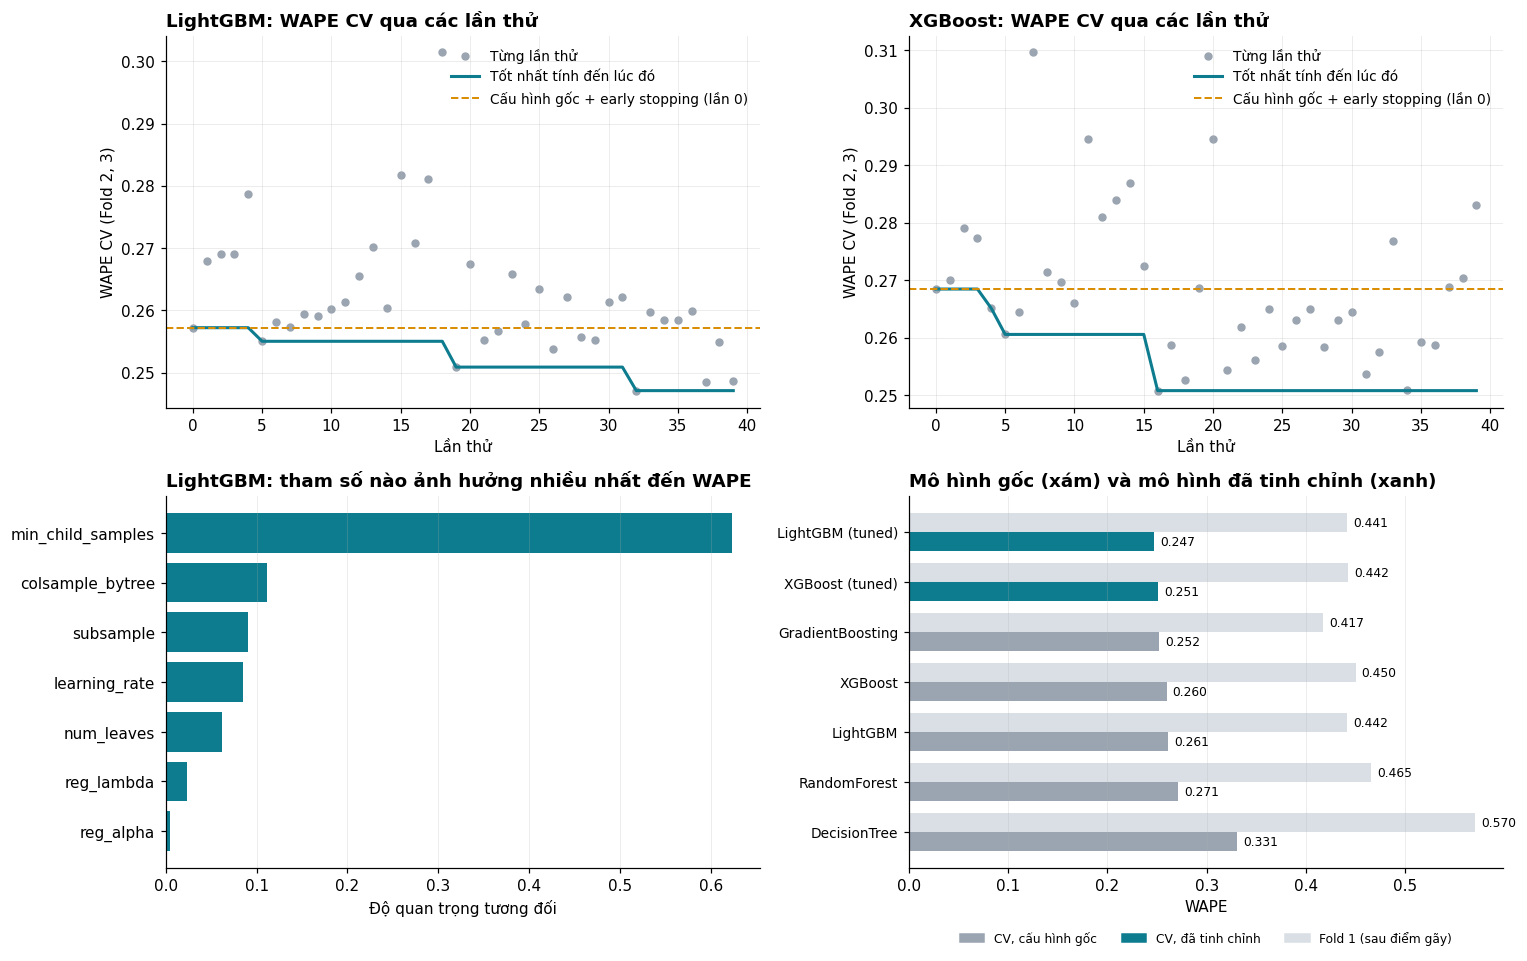

In [64]:
# Hình: (1) quá trình tối ưu, (2) tham số nào quan trọng, (3) so sánh mọi mô hình
fig, axes = plt.subplots(2, 2, figsize=(14, 8.8))
for ax, name in zip(axes[0], studies):
    s = studies[name]
    values = np.array([t.value for t in s.trials])
    ax.scatter(range(len(values)), values, s=20, color=C["grey"], label="Từng lần thử")
    ax.plot(np.minimum.accumulate(values), color=C["accent"], lw=2, label="Tốt nhất tính đến lúc đó")
    ax.axhline(values[0], color=C["warn"], ls="--", lw=1.3, label="Cấu hình gốc + early stopping (lần 0)")
    ax.set(title=f"{name}: WAPE CV qua các lần thử", xlabel="Lần thử", ylabel="WAPE CV (Fold 2, 3)")
    ax.legend(loc="upper right")

try:
    importances = optuna.importance.get_param_importances(studies["LightGBM"])
    imp = pd.Series(importances).sort_values()
    axes[1, 0].barh(imp.index, imp.values, color=C["accent"])
    axes[1, 0].set(title="LightGBM: tham số nào ảnh hưởng nhiều nhất đến WAPE", xlabel="Độ quan trọng tương đối")
    axes[1, 0].grid(axis="y", visible=False)
except Exception as exc:                      # cần đủ số lần thử; nếu không thì bỏ qua thay vì làm hỏng notebook
    axes[1, 0].text(0.5, 0.5, f"Không tính được độ quan trọng tham số\n({type(exc).__name__})", ha="center", transform=axes[1, 0].transAxes)
    axes[1, 0].set_axis_off()

order = summary_all.sort_values("WAPE", ascending=False)
y_pos, bar_h = np.arange(len(order)), 0.38
axes[1, 1].barh(y_pos - bar_h / 2, order.WAPE, bar_h, label="CV (Fold 2, 3)",
                color=[C["accent"] if "tuned" in m else C["grey"] for m in order.index])
axes[1, 1].barh(y_pos + bar_h / 2, order.fold1_WAPE, bar_h, color=C["light"], label="Fold 1 (sau điểm gãy)")
axes[1, 1].set_yticks(y_pos); axes[1, 1].set_yticklabels(order.index, fontsize=9)
for i, (a, b) in enumerate(zip(order.WAPE, order.fold1_WAPE)):
    axes[1, 1].text(a + 0.006, i - bar_h / 2, f"{a:.3f}", va="center", fontsize=8)
    axes[1, 1].text(b + 0.006, i + bar_h / 2, f"{b:.3f}", va="center", fontsize=8)
axes[1, 1].set(title="Mô hình gốc (xám) và mô hình đã tinh chỉnh (xanh)", xlabel="WAPE")
axes[1, 1].legend(handles=[Patch(color=C["grey"], label="CV, cấu hình gốc"), Patch(color=C["accent"], label="CV, đã tinh chỉnh"),
                           Patch(color=C["light"], label="Fold 1 (sau điểm gãy)")],
                  loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=8)
axes[1, 1].grid(axis="y", visible=False)
save_fig("10_tinh_chinh_sieu_tham_so")

In [65]:
# Kết luận tự động: đọc số liệu vừa tính thay vì ghi cứng, để văn bản luôn khớp với kết quả chạy thật.
NOISE = 2.0        # chênh lệch tương đối dưới ngưỡng này (%) coi như nằm trong vùng nhiễu của hai lần cắt CV
for name in studies:
    t = R["tuning"][name]
    # tính phần trăm cải thiện 
    total = 100 * (1 - t["cv_wape_tuned"] / t["cv_wape_default_fixed"])
    # early_stopping đóng góp bao nhiêu vào mức cải thiện 
    from_es = 100 * (1 - t["cv_wape_start_trial"] / t["cv_wape_default_fixed"])
    # Sau khi đã có early_stopping, việc tìm kiếm hyperparameter cải thiện thêm bao nhiêu 
    from_search = 100 * (1 - t["cv_wape_tuned"] / t["cv_wape_start_trial"])
    fold1_change = 100 * (1 - t["fold1_wape_tuned"] / t["fold1_wape_default"])
    print(f"  {name}: CV WAPE {t['cv_wape_default_fixed']:.4f} -> {t['cv_wape_tuned']:.4f} ({total:+.1f}%)."
          f" Trong đó early stopping {from_es:+.1f}%, tìm kiếm tham số {from_search:+.1f}%.")
    print(f"      Fold 1 (không tham gia tinh chỉnh): {t['fold1_wape_default']:.4f} -> {t['fold1_wape_tuned']:.4f} ({fold1_change:+.1f}%)")
    if abs(total) < NOISE:
        print("      => Cấu hình gốc đã gần tối ưu: cải thiện nằm trong vùng nhiễu, không nên báo cáo là 'tinh chỉnh có hiệu quả rõ rệt'.")
    elif fold1_change < 0:
        print("      => CV cải thiện nhưng Fold 1 xấu đi: dấu hiệu quá khớp vào Fold 2, 3. Cần thận trọng với cấu hình này.")
    else:
        print("      => Cải thiện nhất quán cả trên CV lẫn Fold 1.")
print(f"\n  Mô hình tốt nhất theo CV sau tinh chỉnh: {R['chosen_model']} (trước tinh chỉnh: {R['chosen_model_before_tuning']})")

  LightGBM: CV WAPE 0.2612 -> 0.2471 (+5.4%). Trong đó early stopping +1.5%, tìm kiếm tham số +3.9%.
      Fold 1 (không tham gia tinh chỉnh): 0.4416 -> 0.4414 (+0.1%)
      => Cải thiện nhất quán cả trên CV lẫn Fold 1.
  XGBoost: CV WAPE 0.2596 -> 0.2508 (+3.4%). Trong đó early stopping -3.4%, tìm kiếm tham số +6.6%.
      Fold 1 (không tham gia tinh chỉnh): 0.4498 -> 0.4420 (+1.7%)
      => Cải thiện nhất quán cả trên CV lẫn Fold 1.

  Mô hình tốt nhất theo CV sau tinh chỉnh: LightGBM (tuned) (trước tinh chỉnh: GradientBoosting)


## **6.5. Hiệu quả của các nhóm đặc trưng**

In [66]:
HISTORY = ('lag_', 'roll', 'ratio', 'trend', 'cv_')
CALENDAR = ('dow', 'dom', 'month', 'quarter', 'doy', 'days_in', 'is_week',
            'is_eom', 'is_som', 'is_odd', 'fourier')
FEATURE_SETS = {
    'A. hai độ trễ thô': ['lag_28', 'lag_364'],
    'B. tám độ trễ thô': [c for c in features if c.startswith('lag_')],
    'C. thêm trung bình trượt, tỉ số, xu hướng': [c for c in features if c.startswith(HISTORY)],
    'D. thêm lịch và Fourier': [c for c in features if c.startswith(HISTORY + CALENDAR)],
    'E. đầy đủ, thêm Tết và khuyến mãi': features
}

### **Chạy từng bộ đặc trưng**

In [67]:
rows = []
for name, columns in FEATURE_SETS.items():
    scores = cross_validate(columns)
    train, valid = split_by_date(df, *TEST_FOLD[1:])
    model = get_models()['LightGBM']
    model.fit(train[columns], np.log1p(train.revenue.values))
    scores['TEST'] = metrics(valid.revenue.values, np.expm1(model.predict(valid[columns])))['WAPE']
    rows.append({'set': name, 'n_columns': len(columns), **scores})

### **Đọc kết quả**

In [68]:
add_table = pd.DataFrame(rows).set_index('set')
base_cv = add_table['CV'].iloc[0] # chọn A làm baseline 
add_table['vs_A_pct'] = 100 * (add_table.CV / base_cv - 1) # thay đổi bao nhiêu so với A 

shown = {'n_columns': 'cột', 'Fold 2': 'Fold 2', 'Fold 3': 'Fold 3',
         'CV': 'CV', 'vs_A_pct': 'so với A %', 'TEST': 'TEST'}
print(add_table[list(shown)].round(4).rename(columns=shown)
      .rename_axis('bộ đặc trưng').to_string())
print(f'\n Mô hình cơ sở    CV {R['baseline_chosen']['WAPE_cv']:.4f}'
      f'    TEST {R['baseline_chosen']['WAPE_test']:.4f}')
R['feature_sets'] = add_table.to_dict('index')
# 100 * (1 - CV_E / CV_A) # bộ feature đầy đủ giảm bao nhiêu % so với base 
R['feature_total_gain_pct'] = float(100 * (1 - add_table['CV'].iloc[-1] / base_cv))

                                           cột  Fold 2  Fold 3      CV  so với A %    TEST
bộ đặc trưng                                                                              
A. hai độ trễ thô                            2  0.3739  0.4302  0.4020      0.0000  0.3162
B. tám độ trễ thô                            8  0.3208  0.3395  0.3301    -17.8783  0.2489
C. thêm trung bình trượt, tỉ số, xu hướng   22  0.3115  0.3004  0.3060    -23.8943  0.2858
D. thêm lịch và Fourier                     41  0.2804  0.2523  0.2663    -33.7537  0.2287
E. đầy đủ, thêm Tết và khuyến mãi           53  0.2843  0.2381  0.2612    -35.0282  0.2154

 Mô hình cơ sở    CV 0.3570    TEST 0.3315


### **Trên tập kiểm tra**

In [69]:
# kiểm tra điểm test có giảm đều hay không 
monotone_test = bool((add_table['TEST'].diff().dropna() < 0).all())
R['feature_sets_monotone_test'] = monotone_test
print(f'\n Trên kiểm định chéo, WAPE giảm đều từ {base_cv:.4f} xuống '
      f'{add_table['CV'].iloc[-1]:.4f}, tức giảm {R['feature_total_gain_pct']:.1f}%')
if not monotone_test:
    worst = add_table['TEST'].diff().idxmax()
    # ví dụ C là điểm tăng score, thì B là điểm trước C 
    previous = add_table.index[list(add_table.index).index(worst) - 1]
    print(f'\n Trên tập kiểm tra thì bộ {worst} lại tệ hơn bộ trước, {add_table.loc[worst, 'TEST']:.4f}'
          f' so với {add_table.loc[previous, 'TEST']:.4f}')
    R['feature_sets_warning'] = {'set': worst, 'TEST': float(add_table.loc[worst, 'TEST']),
                                 'TEST_previous': float(add_table.loc[previous, 'TEST']),
                                 'CV': float(add_table.loc[worst, 'CV']),
                                 'CV_previous': float(add_table.loc[previous, 'CV'])}

save_results(R, "05_models")


 Trên kiểm định chéo, WAPE giảm đều từ 0.4020 xuống 0.2612, tức giảm 35.0%

 Trên tập kiểm tra thì bộ C. thêm trung bình trượt, tỉ số, xu hướng lại tệ hơn bộ trước, 0.2858 so với 0.2489


# **7. ĐÁNH GIÁ TRÊN TẬP KIỂM TRA**

In [70]:
warnings.filterwarnings("ignore")
R = {}

df = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
features = load_results("04_features")["features"]
previous = load_results("05_models")
baseline = previous["baseline_chosen"]
TUNED_PARAMS = {k: v["params"] for k, v in previous["tuning"].items()}

train, test = split_by_date(df, *TEST_FOLD[1:])
y_train_log = np.log1p(train.revenue.values)
y_test = test.revenue.values

## **7.1. Kết quả dự báo**

In [71]:
print(f"  Tập kiểm tra: {len(test)} ngày, từ {test.date.min().date()}"
      f" đến {test.date.max().date()}")
print(f"  Mô hình chốt theo kiểm định chéo: {previous['chosen_model']}\n")

scores, test_predictions = {}, {}
for model_name, model in get_models().items():
    model.fit(train[features], y_train_log)
    prediction = np.expm1(model.predict(test[features]))
    scores[model_name] = metrics(y_test, prediction)
    test_predictions[model_name] = prediction

# Hai mô hình đã tinh chỉnh ở VI.4b. Cùng quy trình early stopping trên đuôi tập huấn luyện, KHÔNG nhìn TEST.
for base_name, params in TUNED_PARAMS.items():
    model = fit_with_early_stopping(base_name, params, train, features)
    prediction = np.expm1(model.predict(test[features]))
    scores[f"{base_name} (tuned)"] = metrics(y_test, prediction)
    test_predictions[f"{base_name} (tuned)"] = prediction

  Tập kiểm tra: 154 ngày, từ 2022-07-31 đến 2022-12-31
  Mô hình chốt theo kiểm định chéo: LightGBM (tuned)



### **Xếp hạng trên tập kiểm tra**

In [72]:
table = pd.DataFrame(scores).T.sort_values('WAPE')
table['vs_baseline_pct'] = 100 * (table.WAPE / baseline['WAPE_test'] - 1)
print(table.round(4).rename(columns={"vs_baseline_pct": "so với cơ sở %"})
      .rename_axis("mô hình").to_string())
print(f"\n  mô hình cơ sở    WAPE {baseline['WAPE_test']:.4f}")

R['test'] = table.to_dict('index')
R['baseline_test_WAPE'] = baseline['WAPE_test']
R['best_on_test'] = table.index[0]

main_model = 'LightGBM'
main = scores[main_model]
R['main_model'] = main_model
print(f"\n  Tài liệu dùng {main_model} xuyên suốt phần giải thích, WAPE {main['WAPE']:.4f}")
print(f"  và R2 {main['R2']:.4f}, tốt hơn mô hình cơ sở"
      f" {100 * (1 - main['WAPE'] / baseline['WAPE_test']):.1f}%.")
if previous['chosen_model'] != table.index[0]:
    print(f'\n Mô hình chốt theo kiểm định chéo là {previous['chosen_model']} còn mô hình tốt'
          f' nhất trên tập kiểm tra là {table.index[0]}. Hai cái khác nhau,'
          f' và chúng ta vẫn giữ lựa chọn đã chốt theo kiểm định chéo')

                    WAPE    bias      R2  so với cơ sở %
mô hình                                                 
XGBoost           0.2123 -0.1436  0.6532        -35.9530
LightGBM          0.2154 -0.1431  0.6351        -35.0332
RandomForest      0.2235 -0.1271  0.6097        -32.5725
LightGBM (tuned)  0.2286 -0.1260  0.5781        -31.0278
XGBoost (tuned)   0.2337 -0.1633  0.5757        -29.4991
GradientBoosting  0.2357 -0.1828  0.5713        -28.9064
DecisionTree      0.2734 -0.0847  0.4454        -17.5230

  mô hình cơ sở    WAPE 0.3315

  Tài liệu dùng LightGBM xuyên suốt phần giải thích, WAPE 0.2154
  và R2 0.6351, tốt hơn mô hình cơ sở 35.0%.

 Mô hình chốt theo kiểm định chéo là LightGBM (tuned) còn mô hình tốt nhất trên tập kiểm tra là XGBoost. Hai cái khác nhau, và chúng ta vẫn giữ lựa chọn đã chốt theo kiểm định chéo


In [73]:
# Kết luận tự động: tinh chỉnh có ích ngoài mẫu không, và mô hình thắng baseline bao nhiêu
NOISE = 2.0        # chênh lệch tương đối (%) dưới ngưỡng này coi là nằm trong vùng nhiễu
print(f"  Mốc baseline (cùng kỳ năm trước): WAPE {baseline['WAPE_test']:.4f}\n")
R["tuning_on_test"] = {}
for name in ("LightGBM", "XGBoost"):
    default_w, tuned_w = scores[name]["WAPE"], scores[f"{name} (tuned)"]["WAPE"]
    gain = 100 * (1 - tuned_w / default_w)
    R["tuning_on_test"][name] = {"default": default_w, "tuned": tuned_w, "gain_pct": gain}
    print(f"  {name}: TEST WAPE gốc {default_w:.4f} -> tinh chỉnh {tuned_w:.4f} ({gain:+.1f}%)")
    if abs(gain) < NOISE:
        print("     => Khác biệt nằm trong vùng nhiễu: tinh chỉnh không tạo lợi thế rõ trên dữ liệu chưa thấy.")
    elif gain > 0:
        print("     => Lợi thế của tinh chỉnh còn nguyên trên TEST, không chỉ trên CV.")
    else:
        print("     => Tinh chỉnh tốt hơn trên CV nhưng KHÔNG tốt hơn trên TEST: dấu hiệu quá khớp vào CV.")

  Mốc baseline (cùng kỳ năm trước): WAPE 0.3315

  LightGBM: TEST WAPE gốc 0.2154 -> tinh chỉnh 0.2286 (-6.2%)
     => Tinh chỉnh tốt hơn trên CV nhưng KHÔNG tốt hơn trên TEST: dấu hiệu quá khớp vào CV.
  XGBoost: TEST WAPE gốc 0.2123 -> tinh chỉnh 0.2337 (-10.1%)
     => Tinh chỉnh tốt hơn trên CV nhưng KHÔNG tốt hơn trên TEST: dấu hiệu quá khớp vào CV.


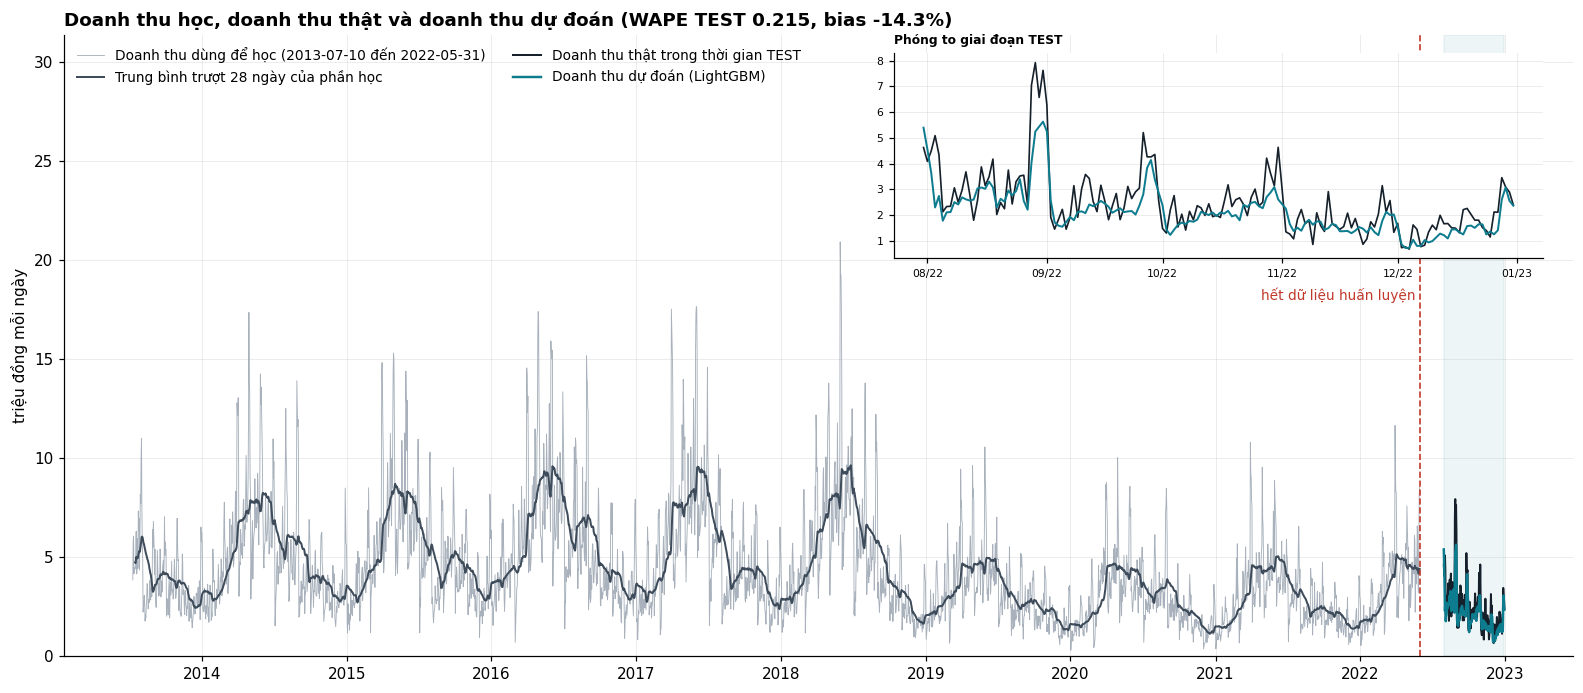

In [74]:
main_pred = test_predictions[main_model]

fig, ax = plt.subplots(figsize=(14.5, 6.4))
ax.plot(train.date, train.revenue / 1e6, color=C["grey"], lw=0.6, alpha=0.85,
        label=f"Doanh thu dùng để học ({train.date.min().date()} đến {train.date.max().date()})")
ax.plot(train.date, train.revenue.rolling(28, min_periods=7).mean() / 1e6, color=C["ink2"], lw=1.3,
        label="Trung bình trượt 28 ngày của phần học")
ax.plot(test.date, y_test / 1e6, color=C["ink"], lw=1.3, label="Doanh thu thật trong thời gian TEST")
ax.plot(test.date, main_pred / 1e6, color=C["accent"], lw=1.6, label=f"Doanh thu dự đoán ({main_model})")
ax.axvspan(test.date.min(), test.date.max(), color=C["accent"], alpha=0.07)
ax.axvline(train.date.max(), color=C["bad"], ls="--", lw=1.1)
y_top = max(train.revenue.max(), y_test.max()) / 1e6
ax.text(train.date.max(), y_top * 0.86, "hết dữ liệu huấn luyện ", color=C["bad"], fontsize=9, ha="right")
ax.set_ylim(0, y_top * 1.5)
ax.set(ylabel="triệu đồng mỗi ngày",
       title=f"Doanh thu học, doanh thu thật và doanh thu dự đoán (WAPE TEST {scores[main_model]['WAPE']:.3f}, bias {scores[main_model]['bias'] * 100:+.1f}%)")
ax.legend(loc="upper left", ncol=2, fontsize=9)

zoom = ax.inset_axes([0.55, 0.64, 0.43, 0.33])
zoom.plot(test.date, y_test / 1e6, color=C["ink"], lw=1.1)
zoom.plot(test.date, main_pred / 1e6, color=C["accent"], lw=1.3)
zoom.set_facecolor("white"); zoom.grid(alpha=0.25)
zoom.set_title("Phóng to giai đoạn TEST", fontsize=8, loc="left")
zoom.tick_params(labelsize=7); zoom.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
save_fig("11_doanh_thu_hoc_thuc_te_va_du_bao")

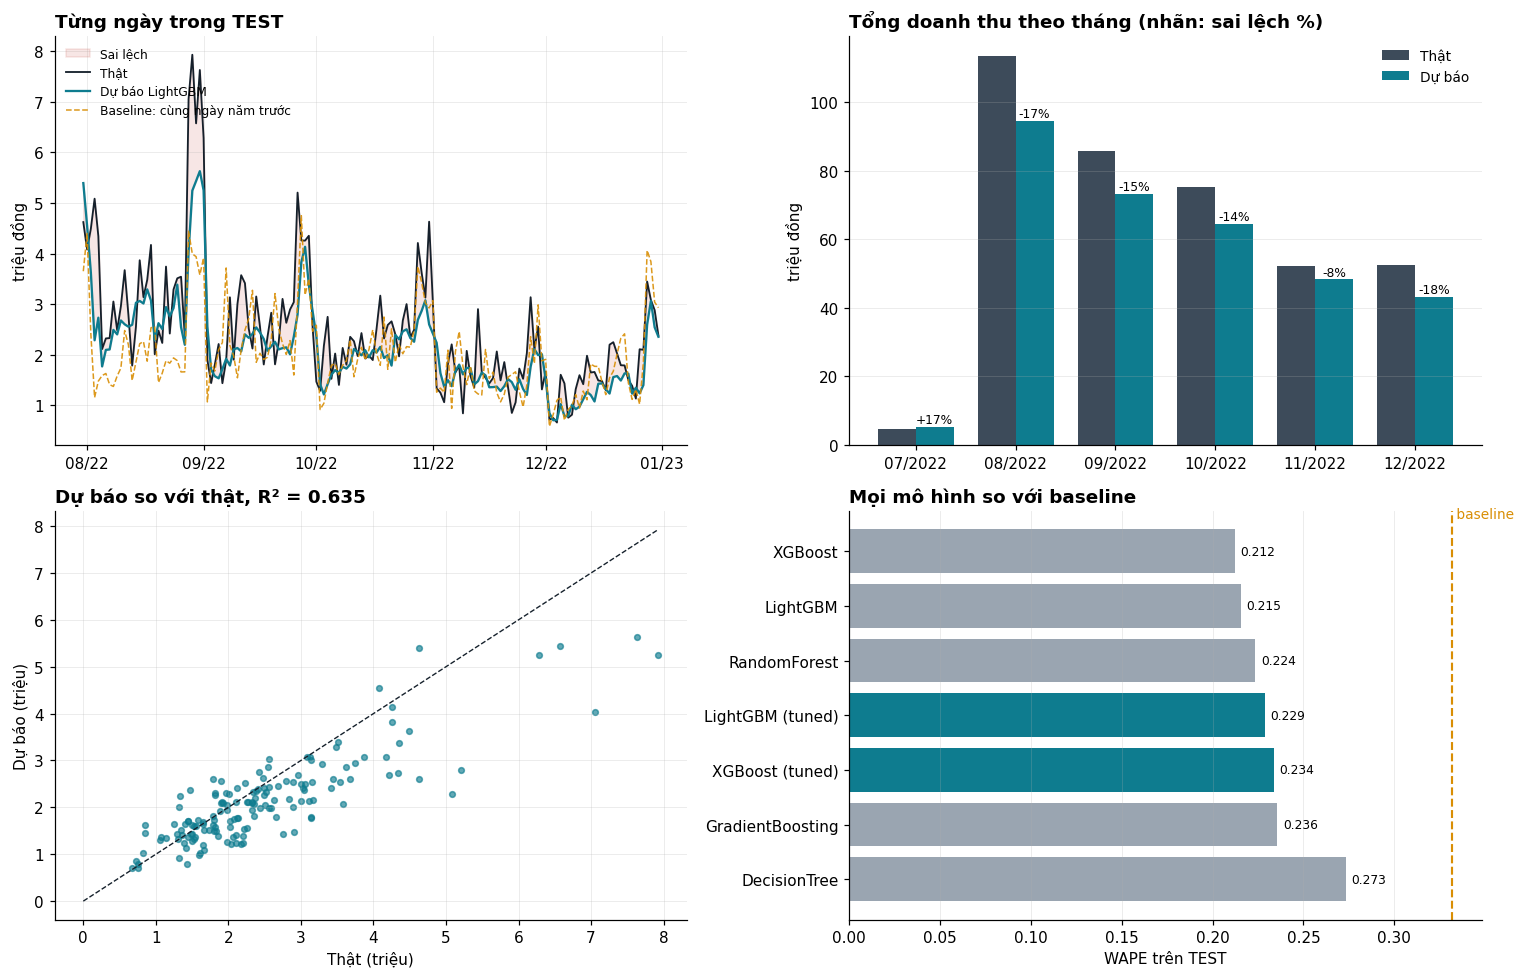

In [75]:
# Hình chi tiết giai đoạn TEST: dự báo so với thật, theo tháng, phân tán, và so với các mô hình khác
base_pred = (df.set_index("date").revenue.reindex(test.date - pd.Timedelta(days=364)).values)   # baseline: cùng ngày năm trước
monthly = (pd.DataFrame({"actual": y_test, "pred": main_pred}, index=test.date).resample("MS").sum() / 1e6)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax = axes[0, 0]
ax.fill_between(test.date, y_test / 1e6, main_pred / 1e6, color=C["bad"], alpha=0.12, label="Sai lệch")
ax.plot(test.date, y_test / 1e6, color=C["ink"], lw=1.2, label="Thật")
ax.plot(test.date, main_pred / 1e6, color=C["accent"], lw=1.5, label=f"Dự báo {main_model}")
ax.plot(test.date, base_pred / 1e6, color=C["warn"], lw=1, ls="--", alpha=0.9, label="Baseline: cùng ngày năm trước")
ax.set(title="Từng ngày trong TEST", ylabel="triệu đồng"); ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))

ax = axes[0, 1]
xm, w = np.arange(len(monthly)), 0.38
ax.bar(xm - w / 2, monthly.actual, w, color=C["ink2"], label="Thật")
ax.bar(xm + w / 2, monthly.pred, w, color=C["accent"], label="Dự báo")
for xi, (a, p) in enumerate(zip(monthly.actual, monthly.pred)):
    ax.text(xi + w / 2, p + monthly.actual.max() * 0.01, f"{100 * (p / a - 1):+.0f}%", ha="center", fontsize=8)
ax.set_xticks(xm); ax.set_xticklabels(monthly.index.strftime("%m/%Y"))
ax.set(title="Tổng doanh thu theo tháng (nhãn: sai lệch %)", ylabel="triệu đồng"); ax.legend(); ax.grid(axis="x", visible=False)

ax = axes[1, 0]
lim = max(y_test.max(), main_pred.max()) / 1e6
ax.scatter(y_test / 1e6, main_pred / 1e6, s=14, color=C["accent"], alpha=0.65)
ax.plot([0, lim], [0, lim], color=C["ink"], lw=0.9, ls="--")
ax.set(xlabel="Thật (triệu)", ylabel="Dự báo (triệu)", title=f"Dự báo so với thật, R² = {scores[main_model]['R2']:.3f}")

ax = axes[1, 1]
order = table.sort_values("WAPE", ascending=False)
ax.barh(order.index, order.WAPE, color=[C["accent"] if "tuned" in m else C["grey"] for m in order.index])
ax.axvline(baseline["WAPE_test"], color=C["warn"], ls="--", lw=1.4)
ax.text(baseline["WAPE_test"], len(order) - 0.45, " baseline", color=C["warn"], fontsize=9, va="bottom")
for i, v in enumerate(order.WAPE):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8)
ax.set(xlabel="WAPE trên TEST", title="Mọi mô hình so với baseline"); ax.grid(axis="y", visible=False)
save_fig("12_chi_tiet_du_bao_tren_test")

## **7.2. Thiên lệch của mô hình**

**Giả thuyết 1:** sai lệch do đổi ngược bằng thang log. Mô hình dự báo trung bình của log, nhưng `expm1` thường thấp hơn trung bình thật. Cách chữa chuẩn là hệ số điều chỉnh Duan

In [76]:
print(f'  {main_model} dự báo thấp hơn thực tế {abs(main['bias']) * 100:.1f}%')

model = get_models()[main_model]
model.fit(train[features], y_train_log)
# tính phần dư trên thang log 
residual_log = np.log1p(y_test) - model.predict(test[features])

# tính duan factor: 
duan_factor = float(np.mean(np.exp(y_train_log - model.predict(train[features]))))

print(f"    trung bình phần dư ngay trên thang log: {residual_log.mean():+.4f},"
      f" tương đương {100 * (np.exp(residual_log.mean()) - 1):+.1f}%")
print(f"    hệ số Duan tính từ phần dư train      : {duan_factor:.4f},"
      f" chỉ chữa được {100 * (duan_factor - 1):+.2f}%")

  LightGBM dự báo thấp hơn thực tế 14.3%
    trung bình phần dư ngay trên thang log: +0.1257, tương đương +13.4%
    hệ số Duan tính từ phần dư train      : 1.0016, chỉ chữa được +0.16%


**Giả thuyết 2:** Mức doanh thu 2022 hồi phục nhanh hơn mức mô hình đã học, nên dự báo bám sát theo mức cũ

In [77]:
raw = pd.read_csv(DATA / "sales_clean.csv", parse_dates=["date"])

def second_half_mean(year):
    window = (raw.date.dt.year == year) & (raw.date.dt.month >= 7)
    return float(raw.loc[window, "revenue"].mean())

vs_2021 = 100 * (second_half_mean(2022) / second_half_mean(2021) - 1)
vs_recent = 100 * (second_half_mean(2022)
                   / np.mean([second_half_mean(y) for y in (2019, 2020, 2021)]) - 1)

print(f"    nửa cuối 2022 so với cùng kỳ 2021        : {vs_2021:+.1f}%")
print(f"    nửa cuối 2022 so với trung bình 2019-2021: {vs_recent:+.1f}%")
print("    ngược lại. Chấp nhận.")

R["bias"] = {"value": float(main["bias"]),
             "residual_log_mean": float(residual_log.mean()),
             "residual_log_pct": float(100 * (np.exp(residual_log.mean()) - 1)),
             "duan_factor": duan_factor,
             "duan_correction_pct": float(100 * (duan_factor - 1)),
             "h2_2022_vs_2021_pct": vs_2021,
             "h2_2022_vs_2019_2021_pct": vs_recent}

R["prediction"] = {"date": [str(d.date()) for d in test.date],
                   "actual": [float(v) for v in y_test],
                   "predicted": [float(v) for v in np.expm1(model.predict(test[features]))]}
save_results(R, "06_evaluate")

    nửa cuối 2022 so với cùng kỳ 2021        : +16.2%
    nửa cuối 2022 so với trung bình 2019-2021: +10.2%
    ngược lại. Chấp nhận.


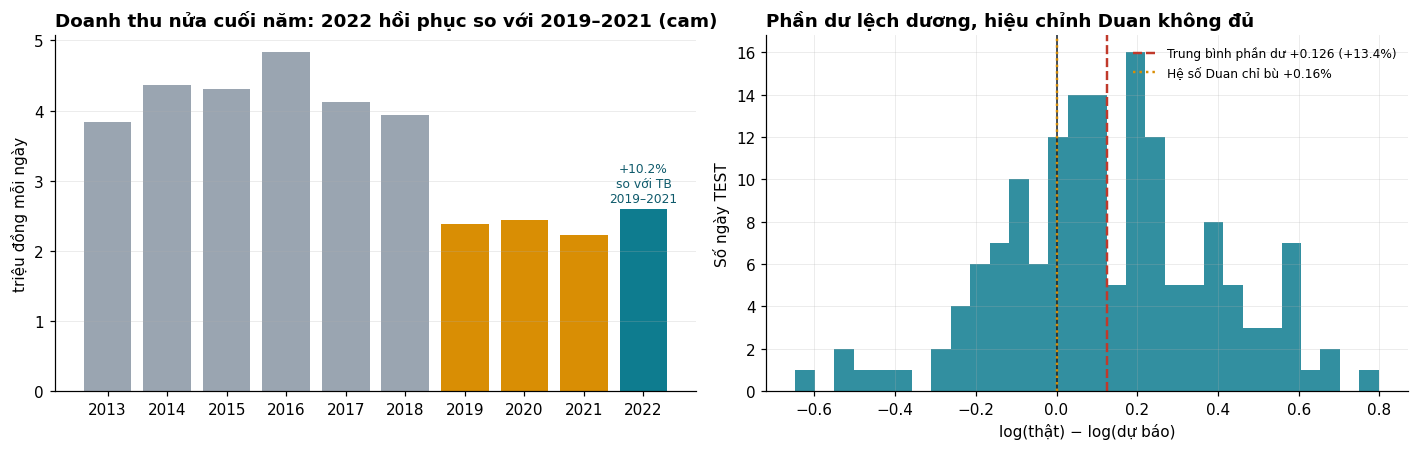

In [78]:
# Hình: (trái) doanh thu nửa cuối năm theo năm, (phải) phân phối phần dư trên thang log
years = list(range(2013, 2023))
h2 = [second_half_mean(y) / 1e6 for y in years]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar([str(y) for y in years], h2,
            color=[C["accent"] if y == 2022 else C["warn"] if 2019 <= y <= 2021 else C["grey"] for y in years])
axes[0].set(ylabel="triệu đồng mỗi ngày", title="Doanh thu nửa cuối năm: 2022 hồi phục so với 2019–2021 (cam)")
axes[0].text(len(years) - 1, h2[-1] + 0.1, f"{vs_recent:+.1f}%\nso với TB\n2019–2021", ha="center", fontsize=8, color=C["accent2"])
axes[0].grid(axis="x", visible=False)

axes[1].hist(residual_log, bins=30, color=C["accent"], alpha=0.85)
axes[1].axvline(0, color=C["ink"], lw=1)
axes[1].axvline(residual_log.mean(), color=C["bad"], lw=1.6, ls="--",
                label=f"Trung bình phần dư {residual_log.mean():+.3f} ({100 * (np.exp(residual_log.mean()) - 1):+.1f}%)")
axes[1].axvline(np.log(duan_factor), color=C["warn"], lw=1.6, ls=":",
                label=f"Hệ số Duan chỉ bù {100 * (duan_factor - 1):+.2f}%")
axes[1].set(xlabel="log(thật) − log(dự báo)", ylabel="Số ngày TEST", title="Phần dư lệch dương, hiệu chỉnh Duan không đủ")
axes[1].legend(loc="upper right", fontsize=8)
save_fig("13_giai_thich_bias")

**Đọc kết quả và quyết định**
- **Giả thuyết 1 bị loại:** hệ số Duan chỉ khoảng 1.0016, tức chỉ chữa được +0.16%, trong khi phần dư trung bình trên thang log tương đương khoảng 13.4%. Hiệu chỉnh kỹ thuật chuẩn không giải thích được độ lệch
- **Giả thuyết 2 được chấp nhận:** doanh thu nửa cuối 2022 cao hơn cùng kỳ 2021 khoảng 16.2% và cao hơn trung bình 2019-2021 khoảng 10.2%. Mô hình học từ các giai đoạn mức thấp hơn, nên dự báo thấp hơn thực tế. Cây quyết định **không ngoại suy** vượt khỏi các mức đã thấy 
- **Một chi tiết đáng chú ý:** ở Fold 1 mô hình dự báo cao (mức doanh thu vừa sụt), còn ở TEST dự báo thấp (mức doanh thu vừa hồi phục). Hai bias trái dấu này có cùng một nguyên nhân gốc: mô hình chậm thích nghi khi mức doanh thu đổi.
- **Quyết định:** không bù khoản thiên lệch bằng cách nhân hệ số cho TEST, vì như vậy là dùng TEST để chọn. Ghi nhận đây là **điểm yếu đã biết** của mô hình và đề xuất hướng cải tiến ở phần cuối (dự báo tỉ lệ so với mức gần đây, thêm một trọng số cho dữ liệu)

# **8. GIẢI THÍCH MÔ HÌNH BẰNG SHAP**

In [ ]:
warnings.filterwarnings("ignore")
R = {}

try:
    import shap
except ImportError:                     # thư viện chưa có thì cài rồi nạp lại
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "shap",
                    "--break-system-packages"], check=True)
    import shap

df = pd.read_csv(DATA / f"features_h{H}.csv", parse_dates=["date"])
features = load_results("04_features")["features"]
GROUP_INFO = load_results("04_features")["groups"]

train, test = split_by_date(df, *TEST_FOLD[1:])
y_train_log = np.log1p(train.revenue.values)
y_test = test.revenue.values

# Giải thích đúng mô hình đã tinh chỉnh ở 6.4b, cùng quy trình early stopping như Mục 7
TUNED_PARAMS = {k: v["params"] for k, v in load_results("05_models")["tuning"].items()}
model = fit_with_early_stopping("LightGBM", TUNED_PARAMS["LightGBM"], train, features)
prediction_log = model.predict(test[features])
score = metrics(y_test, np.expm1(prediction_log))


## **8.1. Mức quan trọng của từng đặc trưng**

In [80]:
print(f"  Mô hình giải thích: LightGBM (đã tinh chỉnh), {len(features)} đặc trưng,"
      f" WAPE {score['WAPE']:.4f} và R2 {score['R2']:.4f}")
print(f"  Tập giải thích: {len(test)} ngày của tập kiểm tra,"
      f" từ {test.date.min().date()} đến {test.date.max().date()}\n")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test[features])
base_value = float(np.ravel(explainer.expected_value)[0])

# Trung bình trị tuyệt đối trên toàn tập kiểm tra: mức quan trọng toàn cục.
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=features)
total_abs = float(mean_abs.sum())
ranking = mean_abs.sort_values(ascending=False)

top12 = ranking.head(12).to_frame("TB |SHAP|")
top12["tỉ trọng %"] = 100 * top12["TB |SHAP|"] / total_abs
print(top12.round(4).rename_axis("đặc trưng").to_string())

R["global_shap"] = {"n_test_days": int(len(test)),
                    "base_value": base_value,
                    "total_mean_abs": total_abs,
                    "top12": ranking.head(12).to_dict()}

# Gộp theo bốn nhóm đặc trưng. Cần cả cột trung bình mỗi cột vì tổng của một
# nhóm lớn hơn một phần chỉ do nhóm đó có nhiều cột hơn.


  Mô hình giải thích: LightGBM (đã tinh chỉnh), 53 đặc trưng, WAPE 0.2286 và R2 0.5781
  Tập giải thích: 154 ngày của tập kiểm tra, từ 2022-07-31 đến 2022-12-31

                 TB |SHAP|  tỉ trọng %
đặc trưng                             
lag364_smooth7      0.2324     27.4551
lag_364             0.1142     13.4914
lag364_smooth28     0.0804      9.5002
roll_mean_7         0.0535      6.3261
fourier_sin1        0.0381      4.4991
lag_91              0.0345      4.0771
lag_28              0.0295      3.4825
dom_reverse         0.0242      2.8645
roll_mean_364       0.0214      2.5254
promo_disc_max      0.0207      2.4481
fourier_sin2        0.0169      1.9970
roll_mean_28        0.0123      1.4570


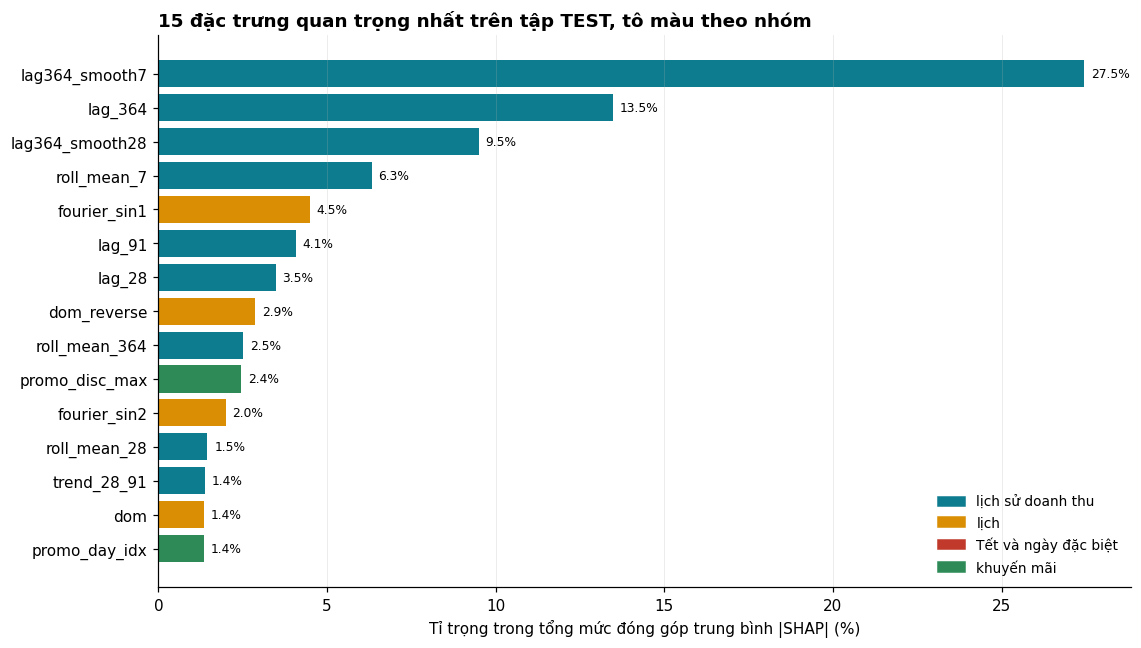

In [81]:
# Hình 1: mức quan trọng toàn cục, tô màu theo nhóm đặc trưng
feature_group = {c: g for g, info in GROUP_INFO.items() for c in info["columns"]}
group_colors = {"lịch sử doanh thu": C["accent"], "lịch": C["warn"],
                "Tết và ngày đặc biệt": C["bad"], "khuyến mãi": C["good"]}
top15 = ranking.head(15)[::-1]
fig, ax = plt.subplots(figsize=(10.5, 6))
ax.barh(top15.index, 100 * top15.values / total_abs, color=[group_colors[feature_group[c]] for c in top15.index])
for i, v in enumerate(100 * top15.values / total_abs):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
ax.legend(handles=[Patch(color=col, label=g) for g, col in group_colors.items()], loc="lower right")
ax.set(xlabel="Tỉ trọng trong tổng mức đóng góp trung bình |SHAP| (%)",
       title="15 đặc trưng quan trọng nhất trên tập TEST, tô màu theo nhóm")
ax.grid(axis="y", visible=False)
save_fig("14_shap_muc_quan_trong_toan_cuc")

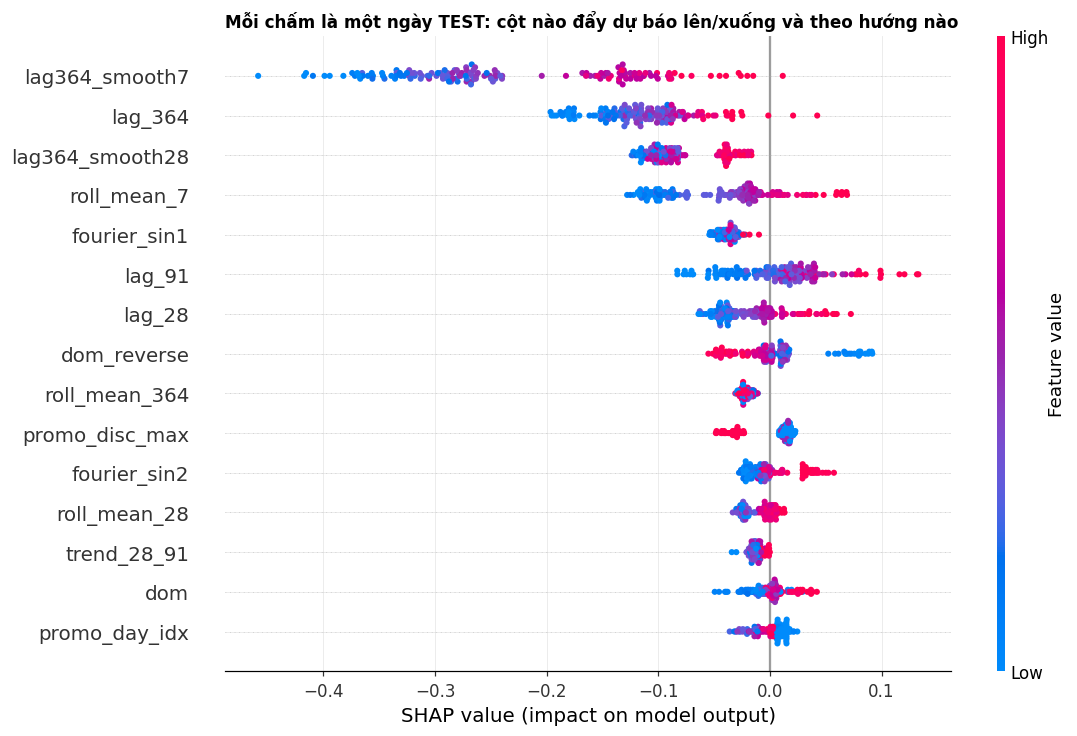

In [82]:
# Hình 2: biểu đồ ong (beeswarm). Mỗi chấm là một ngày TEST; màu là giá trị của cột (đỏ = cao, xanh = thấp);
# vị trí ngang là SHAP (phải = đẩy dự báo lên). Cho biết HƯỚNG tác động, không chỉ độ lớn.
shap.summary_plot(shap_values, test[features], max_display=15, show=False, plot_size=(10.5, 6.8))
plt.title("Mỗi chấm là một ngày TEST: cột nào đẩy dự báo lên/xuống và theo hướng nào", loc="left", fontsize=11, fontweight="bold")
save_fig("15_shap_beeswarm")

### **Gộp theo bốn đặc trưng**

In [83]:
R["group_shap"] = {}
for group_name, info in GROUP_INFO.items():
    group_sum = float(mean_abs[info["columns"]].sum())
    n_columns = int(info["n_columns"])
    R["group_shap"][group_name] = {"total": group_sum,
                                   "share_pct": 100 * group_sum / total_abs,
                                   "n_columns": n_columns,
                                   "mean_per_column": group_sum / n_columns}
print(pd.DataFrame(R["group_shap"]).T.round(4)
      .astype({"n_columns": int}).rename_axis("nhóm").to_string())

top_group = max(R["group_shap"], key=lambda k: R["group_shap"][k]["share_pct"])
print(f"\n  Nhóm {top_group} chiếm {R['group_shap'][top_group]['share_pct']:.1f}% tổng mức")

# Phép kiểm tính cộng tính: nền cộng tổng SHAP phải bằng đúng dự báo của mô hình.

                       total  share_pct  n_columns  mean_per_column
nhóm                                                               
lịch sử doanh thu     0.6477    76.5289         24           0.0270
lịch                  0.1580    18.6656         19           0.0083
Tết và ngày đặc biệt  0.0063     0.7477          4           0.0016
khuyến mãi            0.0343     4.0577          6           0.0057

  Nhóm lịch sử doanh thu chiếm 76.5% tổng mức


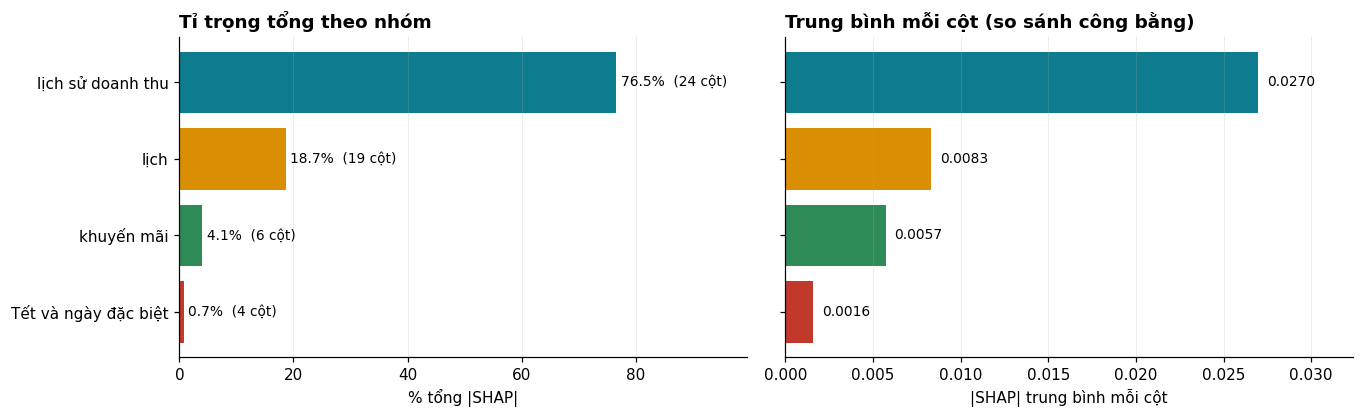

In [84]:
# Hình: tỉ trọng theo nhóm, và trung bình MỖI CỘT (loại hiệu ứng nhiều cột hơn thì tổng lớn hơn)
group_table = pd.DataFrame(R["group_shap"]).T.sort_values("share_pct", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
axes[0].barh(group_table.index, group_table.share_pct, color=[group_colors[g] for g in group_table.index])
for i, (v, n) in enumerate(zip(group_table.share_pct, group_table.n_columns)):
    axes[0].text(v + 0.8, i, f"{v:.1f}%  ({int(n)} cột)", va="center", fontsize=9)
axes[0].set(xlim=(0, group_table.share_pct.max() * 1.3), title="Tỉ trọng tổng theo nhóm", xlabel="% tổng |SHAP|")
axes[1].barh(group_table.index, group_table.mean_per_column, color=[group_colors[g] for g in group_table.index])
for i, v in enumerate(group_table.mean_per_column):
    axes[1].text(v + 0.0005, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].set(xlim=(0, group_table.mean_per_column.max() * 1.2), title="Trung bình mỗi cột (so sánh công bằng)", xlabel="|SHAP| trung bình mỗi cột")
axes[1].set_yticklabels([])
for ax in axes:
    ax.grid(axis="y", visible=False)
save_fig("16_shap_theo_nhom")

**Đọc kết quả và quyết định.**
- **Nhóm lịch sử doanh thu chiếm phần lớn** mức đóng góp (ở lần chạy gốc là khoảng 73%) tiếp theo là nhóm lịch (khoảng 21%), khuyến mãi (khoảng 4%) và Tết (khoảng 1.5%). Số liệu của lần chạy này được in ở ô trên và vẽ ở hình.
- **Vì sao phải xem cả cột "trung bình mỗi cột": nhóm lịch sử có 24 cột nên tổng lớn hơn phần vì số lượng. Trung bình mỗi cột mới cho so sánh công bằng giữa nhóm 24 cột và nhóm chỉ 4-6 cột.
- **Đặc trung tương quan chia sẻ "công":** `lag364_smooth7`, `lag364`, `lag364_smooth28`, `roll_mean_364` đều là "cùng kỳ năm ngoái" dưới các dạng khác nhau, nên SHAP chia sẻ tín hiệu cho cả nhóm. Đánh giá từng cột riêng sẽ đánh giá thấp tầm quan trọng của khái niệm "cùng kỳ năm ngoái". Đây là lý do nên báo cáo theo nhóm và theo họ đặc trưng.
- **Vòng khép kín EDA -> SHAP:** EDA kỳ vọng nhóm Tết đóng góp thấp vì đó phần lớn là hiệu ứng tháng; SHAP xác nhận. 
- **Lưu ý cách đọc:** SHAP nói mô hình đã dùng cột nào, không nói cột nào gây ra doanh thu. `promo_disc_max` có SHAP dương không chứng minh khuyến mãi làm tăng doanh thu. 